# Streaming analysis: selection behavior under domain shift

Core narrative: **content-aware filtering outperforms random selection when the
stream contains domain shift (urban / rural / highway blocks), at the same
bandwidth budget.**

Sections:

1. **Setup** -- run discovery, manifest ordering, bootstrap composition.
2. **mAP along the stream** -- headline result with domain-block annotations.
3. **Accept-rate dynamics** -- realized accept rate at block boundaries.
4. **Score separation** -- violin plots: accepts vs rejects.
5. **Acceptance-rate breakdown** -- metadata composition and conditional rates.
6. **Category-level acceptance** -- per-class accept/reject fractions.
7. **Inter-accept gaps** -- temporal thinning vs memoryless random.
8. **Object-count scatter** -- accepted frames cover denser scenes.
9. **Forgetting analysis** -- early-vs-late per-class AP (catastrophic forgetting proxy).
10. **Summary table** -- best/last mAP and duration per variant.
11. **Per-domain acceptance breakdown** -- accept rate by scene bucket.
12. **Cumulative accepts** -- cumulative accepted frames along the stream.
13. **Pedestrian AP** -- headline class-level figure.
14. **Per-domain mAP** -- average mAP within each domain block.

**Data**: `checkpoints.csv`, `filter_stats.csv`, `decisions.csv`, and manifest from each run's `config.yaml`.

See `02_federated_analysis.ipynb` for federated experiment results.

## 1 Setup

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams.update({"figure.dpi": 140, "font.size": 9,
                     "axes.titlesize": 10, "axes.labelsize": 9,
                     "legend.fontsize": 8, "xtick.labelsize": 8,
                     "ytick.labelsize": 8, "figure.facecolor": "white"})

sys.path.insert(0, str(Path.cwd() / "notebooks"))
if not (Path.cwd() / "pyproject.toml").exists():
    sys.path.insert(0, str(Path.cwd().parent / "notebooks"))

import analysis_helpers as ah

PROJECT_ROOT = ah.find_project_root()
OUTPUTS = PROJECT_ROOT / "outputs"

SEED: int | None = None
SUBSAMPLE_N = 12_000
RNG = 42

PALETTE: dict[str, str] = {
    # Baselines -- city-day bootstrap
    "no_filter_cityday_road_type": "#2ca02c",
    "random_filter_cityday_road_type": "#ff7f0e",
    # Distribution threshold -- city-day bootstrap
    "dist_thresh_cityday_road_type_p10": "#1f77b4",
    "dist_thresh_cityday_reverse_p10": "#d62728",
    # Baselines -- city-mixed bootstrap
    "no_filter_citymix_road_type": "#8c564b",
    "random_filter_citymix_road_type": "#bcbd22",
    # Distribution threshold -- city-mixed bootstrap
    "dist_thresh_citymix_road_type_p10": "#9467bd",
    "dist_thresh_citymix_reverse_p10": "#e377c2",
    "dist_thresh_citymix_conditions_p10": "#17becf",
}

print("Project:", PROJECT_ROOT)

Project: /mnt/tier2/users/u103957/stream-active-FL


In [2]:
runs_df = ah.discover_runs(OUTPUTS)


def pick(pipeline: str, variant: str, seed: int | None = SEED) -> Path | None:
    return ah.pick_latest_run(runs_df, pipeline, variant, seed=seed)


def _runs_non_null(raw: dict[str, Path | None]) -> dict[str, Path]:
    out: dict[str, Path] = {}
    for k, v in raw.items():
        if v is not None:
            out[k] = v
    return out


RUN: dict[str, Path] = _runs_non_null(
    {
        # City-day bootstrap
        "no_filter_cityday_road_type": pick("streaming", "no_filter_cityday_road_type"),
        "random_filter_cityday_road_type": pick("streaming", "random_filter_cityday_road_type"),
        "dist_thresh_cityday_road_type_p10": pick("streaming", "dist_thresh_cityday_road_type_p10"),
        "dist_thresh_cityday_reverse_p10": pick("streaming", "dist_thresh_cityday_reverse_p10"),
        # City-mixed bootstrap
        "no_filter_citymix_road_type": pick("streaming", "no_filter_citymix_road_type"),
        "random_filter_citymix_road_type": pick("streaming", "random_filter_citymix_road_type"),
        "dist_thresh_citymix_road_type_p10": pick("streaming", "dist_thresh_citymix_road_type_p10"),
        "dist_thresh_citymix_reverse_p10": pick("streaming", "dist_thresh_citymix_reverse_p10"),
        "dist_thresh_citymix_conditions_p10": pick("streaming", "dist_thresh_citymix_conditions_p10"),
    }
)

MANIFESTS: dict[str, dict] = {}
for k, p in sorted(RUN.items()):
    cfg = ah.load_run_config(p)
    ordering = "?"
    man = ah.load_manifest(PROJECT_ROOT, str(cfg.get("manifest_path", "")))
    if man:
        ordering = ah.ordering_summary(man)
        MANIFESTS[k] = man
    print(f"{k:40s}  seed={cfg.get('seed')}  ordering={ordering}")
    print(f"{'':40s}  {p}")

MANIFEST = next(iter(MANIFESTS.values()), None)

dist_thresh_cityday_reverse_p10           seed=42  ordering=road_type_reverse_blocks | blocks: ['smaller-rural', 'arterial-rural', 'highway', 'arterial-urban', 'city']
                                          /mnt/tier2/users/u103957/stream-active-FL/outputs/streaming/dist_thresh_cityday_reverse_p10/2026-04-12_21-32-13
dist_thresh_cityday_road_type_p10         seed=42  ordering=road_type_blocks | blocks: ['city', 'arterial-urban', 'highway', 'arterial-rural', 'smaller-rural']
                                          /mnt/tier2/users/u103957/stream-active-FL/outputs/streaming/dist_thresh_cityday_road_type_p10/2026-04-12_21-32-13
no_filter_cityday_road_type               seed=42  ordering=road_type_blocks | blocks: ['city', 'arterial-urban', 'highway', 'arterial-rural', 'smaller-rural']
                                          /mnt/tier2/users/u103957/stream-active-FL/outputs/streaming/no_filter_cityday_road_type/2026-04-12_21-32-13
random_filter_cityday_road_type           seed=42  o

In [3]:
# Load enriched decisions (manifest merge only -- no ZOD for speed).
# Set SKIP_ZOD=False and ensure STREAM_ACTIVE_FL_ZOD_ROOT is set to
# add scene_bucket columns for road-type analysis.
SKIP_ZOD = True
_zod = None if SKIP_ZOD else os.environ.get("STREAM_ACTIVE_FL_ZOD_ROOT")

ENRICHED: dict[str, pd.DataFrame] = {}
for key, rdir in RUN.items():
    df = ah.load_enriched_streaming_decisions(rdir, PROJECT_ROOT, zod_root=_zod)
    if not df.empty:
        ENRICHED[key] = df
        print(f"{key:30s}  {len(df):>6d} rows")

dist_thresh_cityday_road_type_p10   84972 rows
dist_thresh_cityday_reverse_p10   84972 rows
no_filter_cityday_road_type      84972 rows
random_filter_cityday_road_type   84972 rows


### Bootstrap composition summary

Content of each bootstrap prefix (road_type, time_of_day, Pedestrian %).
Crucial for interpreting why the distribution filter behaves differently across experiments.

In [4]:
from collections import Counter

_bootstrap_frames = 5000

_BOOTSTRAP_NAMES: dict[str, str] = {
    "cityday": "City-Day (5k city + day)",
    "citymix": "City-Mixed (5k city, proportional ToD)",
}

def _bootstrap_tag(variant: str) -> str:
    """Infer the bootstrap type from the variant name."""
    if "cityday" in variant:
        return "cityday"
    if "citymix" in variant:
        return "citymix"
    return "unknown"

for k, man in MANIFESTS.items():
    frames = man.get("frames", [])
    train_frames = [f for f in frames if f.get("split") == "train"]
    boot = train_frames[:_bootstrap_frames] if len(train_frames) >= _bootstrap_frames else []
    if not boot:
        continue

    boot_tag = _bootstrap_tag(k)
    boot_label = _BOOTSTRAP_NAMES.get(boot_tag, boot_tag)

    rt_dist = Counter(f.get("road_type", "?") for f in boot)
    tod_dist = Counter(f.get("time_of_day", "?") for f in boot)
    ped_count = sum(1 for f in boot if "Pedestrian" in (f.get("categories_present") or []))

    print(f"\n{k}  (bootstrap={boot_label})")
    print(f"  road_type:    {dict(rt_dist)}")
    print(f"  time_of_day:  {dict(tod_dist)}")
    print(f"  Pedestrian:   {ped_count}/{len(boot)} ({ped_count/len(boot)*100:.1f}%)")

    ordering = man.get("ordering", {})
    if ordering.get("bootstrap_frames"):
        print(f"  [manifest records bootstrap_frames={ordering['bootstrap_frames']}]")


dist_thresh_cityday_reverse_p10  (bootstrap=City-Day (5k city + day))
  road_type:    {'city': 5000}
  time_of_day:  {'day': 5000}
  Pedestrian:   4603/5000 (92.1%)
  [manifest records bootstrap_frames=5000]

dist_thresh_cityday_road_type_p10  (bootstrap=City-Day (5k city + day))
  road_type:    {'city': 5000}
  time_of_day:  {'day': 5000}
  Pedestrian:   4603/5000 (92.1%)
  [manifest records bootstrap_frames=5000]

no_filter_cityday_road_type  (bootstrap=City-Day (5k city + day))
  road_type:    {'city': 5000}
  time_of_day:  {'day': 5000}
  Pedestrian:   4603/5000 (92.1%)
  [manifest records bootstrap_frames=5000]

random_filter_cityday_road_type  (bootstrap=City-Day (5k city + day))
  road_type:    {'city': 5000}
  time_of_day:  {'day': 5000}
  Pedestrian:   4603/5000 (92.1%)
  [manifest records bootstrap_frames=5000]


## 2 mAP along the stream (headline result)

Per-class and aggregate mAP from `checkpoints.csv`, with domain-block boundaries marked.  This is the main result figure: distribution filter should outperform random under domain shift.

dist_thresh_cityday_reverse_p10           5 transitions
dist_thresh_cityday_road_type_p10         5 transitions
no_filter_cityday_road_type               5 transitions
random_filter_cityday_road_type           5 transitions


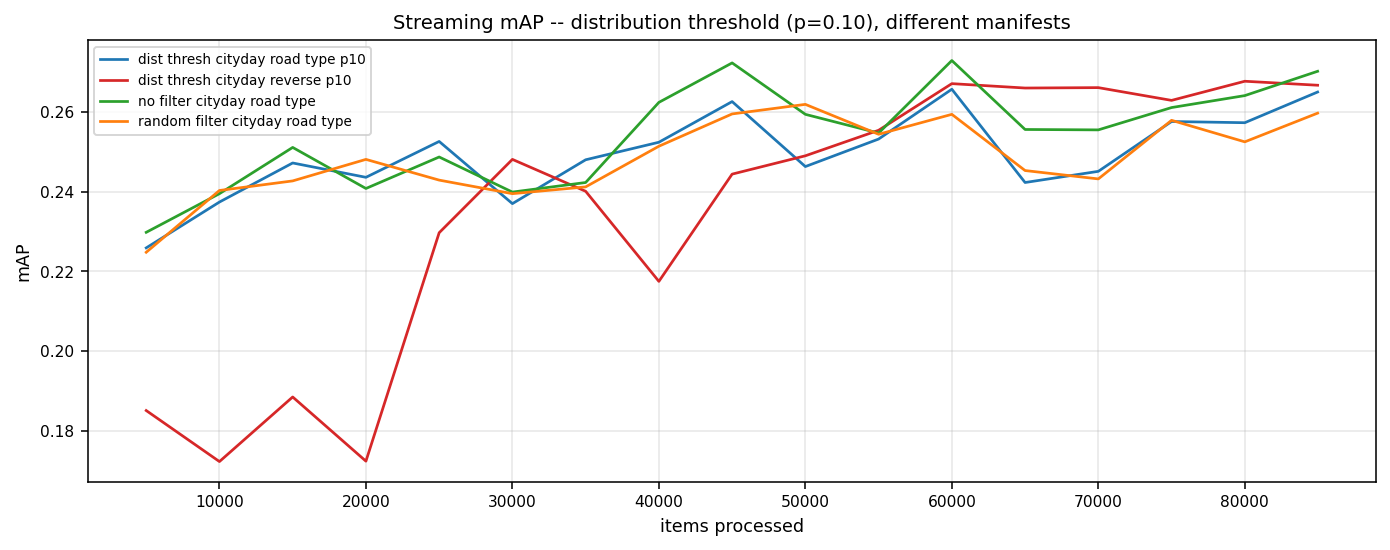

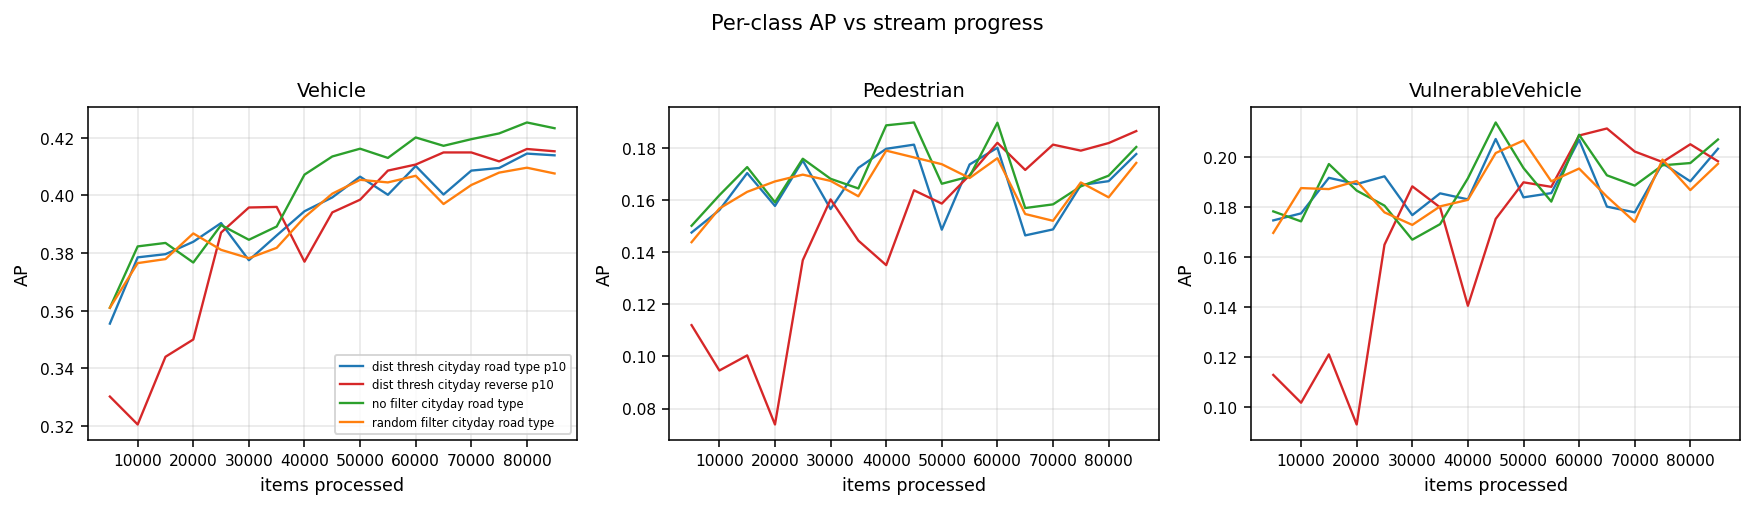

In [5]:
# --- Per-run block boundary info ---
_bootstrap_frames = 5000

# Compute block transitions per variant (each may use a different manifest)
BLOCK_TRANS_PER_RUN: dict[str, list[tuple[int, str]]] = {}
for k, man in MANIFESTS.items():
    bt = ah.block_transitions(man, bootstrap_frames=_bootstrap_frames)
    BLOCK_TRANS_PER_RUN[k] = bt
    print(f"{k:40s}  {len(bt)} transitions")

# Domain colour map (covers road_type, road_type_time, conditions, urban_rural)
_DOMAIN_COLORS: dict[str, str] = {
    "city": "#1f77b4", "arterial-urban": "#aec7e8", "highway": "#ff7f0e",
    "arterial-rural": "#98df8a", "smaller-rural": "#2ca02c",
    "urban": "#1f77b4", "rural": "#2ca02c", "other": "#999999",
    "city_day": "#1f77b4", "city_twilight": "#6baed6", "city_night": "#08306b",
    "arterial-urban_day": "#aec7e8", "arterial-urban_twilight": "#9ecae1",
    "arterial-urban_night": "#4292c6",
    "highway_day": "#ff7f0e", "highway_twilight": "#fd8d3c", "highway_night": "#d94801",
    "arterial-rural_day": "#98df8a", "arterial-rural_twilight": "#74c476",
    "arterial-rural_night": "#238b45",
    "smaller-rural_day": "#2ca02c", "smaller-rural_twilight": "#006d2c",
    "smaller-rural_night": "#00441b",
    "clear": "#f1c40f", "cloudy": "#95a5a6", "fog": "#7f8c8d",
    "rain_wet": "#3498db", "snow": "#ecf0f1",
}
_DOMAIN_SHORT: dict[str, str] = {
    "city": "City", "arterial-urban": "Art-Urb", "highway": "Hwy",
    "arterial-rural": "Art-Rur", "smaller-rural": "Sm-Rur",
    "urban": "Urban", "rural": "Rural", "other": "Other",
    # road_type × time_of_day
    "city_day": "City☀", "city_twilight": "City◑", "city_night": "City☾",
    "arterial-urban_day": "ArtU☀", "arterial-urban_twilight": "ArtU◑",
    "arterial-urban_night": "ArtU☾",
    "highway_day": "Hwy☀", "highway_twilight": "Hwy◑", "highway_night": "Hwy☾",
    "arterial-rural_day": "ArtR☀", "arterial-rural_twilight": "ArtR◑",
    "arterial-rural_night": "ArtR☾",
    "smaller-rural_day": "SmR☀", "smaller-rural_twilight": "SmR◑",
    "smaller-rural_night": "SmR☾",
    # conditions
    "clear": "Clear", "cloudy": "Cloudy", "fog": "Fog",
    "rain_wet": "Rain/Wet", "snow": "Snow",
}

def add_block_bands(
    ax: Axes,
    variant: str | None = None,
    alpha: float = 0.13,
) -> None:
    """Shade domain-block regions for a specific variant.
    If variant is None, do nothing (useful for cross-manifest comparison plots).
    Bands are clipped to the actual plotted data extent (ax.dataLim).
    """
    if variant is None:
        return
    bt = BLOCK_TRANS_PER_RUN.get(variant, [])
    if not bt:
        return
    data_end = ax.dataLim.x1
    if not np.isfinite(data_end) or data_end <= 0:
        return
    for i, (idx, label) in enumerate(bt):
        end = bt[i + 1][0] if i + 1 < len(bt) else data_end
        if idx >= data_end:
            continue
        end = min(end, data_end)
        color = _DOMAIN_COLORS.get(label, "#cccccc")
        ax.axvspan(idx, end, color=color, alpha=alpha, zorder=0)
        ax.axvline(idx, color=color, alpha=0.35, lw=0.6, ls="--", zorder=0)
        width = end - idx
        if width < 1500:
            continue
        mid = (idx + end) / 2
        short = _DOMAIN_SHORT.get(label, label[:6])
        ax.text(mid, ax.get_ylim()[1], short, ha="center", va="bottom",
                fontsize=5.5, style="italic", color=color, fontweight="bold")


# --- Headline: aggregate mAP (all 4 variants, no domain bands) ---
variants_main = list(RUN.keys())

fig, ax = plt.subplots(figsize=(10, 4))
for v in variants_main:
    if v not in RUN:
        continue
    ck = ah.read_csv(RUN[v] / "checkpoints.csv")
    if ck is None or ck.empty or "mAP" not in ck.columns:
        continue
    label = v.replace("_", " ")
    ax.plot(ck["items_processed"], ck["mAP"], label=label, color=PALETTE.get(v), lw=1.4)
ax.set_xlabel("items processed")
ax.set_ylabel("mAP")
ax.set_title("Streaming mAP -- distribution threshold (p=0.10), different manifests")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Per-class AP ---
ap_cols = None
series_list: list[tuple[str, pd.DataFrame]] = []
for v in variants_main:
    if v not in RUN:
        continue
    ck = ah.read_csv(RUN[v] / "checkpoints.csv")
    if ck is None or ck.empty:
        continue
    cols = ah.per_class_ap_columns(ck)
    if not cols:
        continue
    if ap_cols is None:
        ap_cols = cols
    series_list.append((v, ck))

if series_list and ap_cols is not None:
    plot_cols: list[str] = list(ap_cols)
    n_c = len(plot_cols)
    fig, axes = plt.subplots(1, n_c, figsize=(4.2 * n_c, 3.5), squeeze=False)
    for i, col in enumerate(plot_cols):
        a = axes[0][i]
        for label, ck in series_list:
            if col not in ck.columns:
                continue
            a.plot(ck["items_processed"], ck[col], label=label.replace("_", " "),
                   color=PALETTE.get(label), lw=1.2)
        a.set_title(col.replace("AP_", ""))
        a.set_xlabel("items processed")
        a.set_ylabel("AP")
        a.grid(True, alpha=0.3)
    axes[0][0].legend(fontsize=6, loc="best")
    fig.suptitle("Per-class AP vs stream progress", y=1.02)
    plt.tight_layout()
    plt.show()

## 3 Accept-rate dynamics

Per-checkpoint accept rate from `filter_stats.csv`.  Distribution filter should show rate spikes at block boundaries (novel embeddings after domain shift); random stays flat.

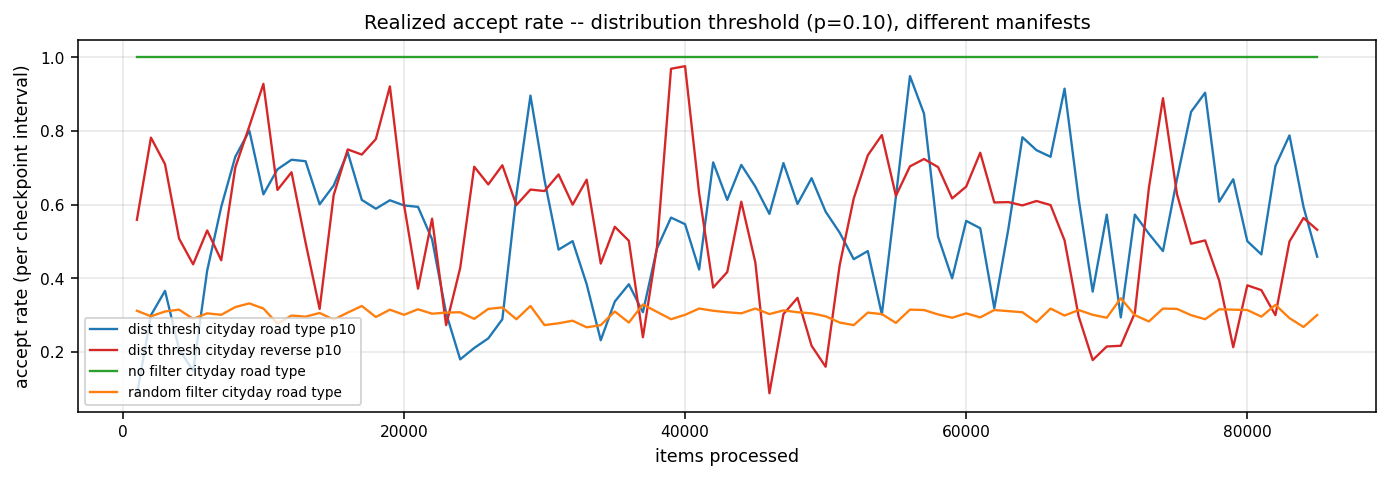

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))

for v in variants_main:
    if v not in RUN:
        continue
    fs = ah.read_csv(RUN[v] / "filter_stats.csv")
    if fs is None or fs.empty or "accept_rate" not in fs.columns:
        continue
    ax.plot(fs["items_processed"], fs["accept_rate"],
            label=v.replace("_", " "), color=PALETTE.get(v), lw=1.2)

ax.set_xlabel("items processed")
ax.set_ylabel("accept rate (per checkpoint interval)")
ax.set_title("Realized accept rate -- distribution threshold (p=0.10), different manifests")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4 Score separation (accepted vs rejected)

For the distribution filter, `filter_score` should be higher for accepted frames -- sanity check that the policy implements a monotonic accept rule.

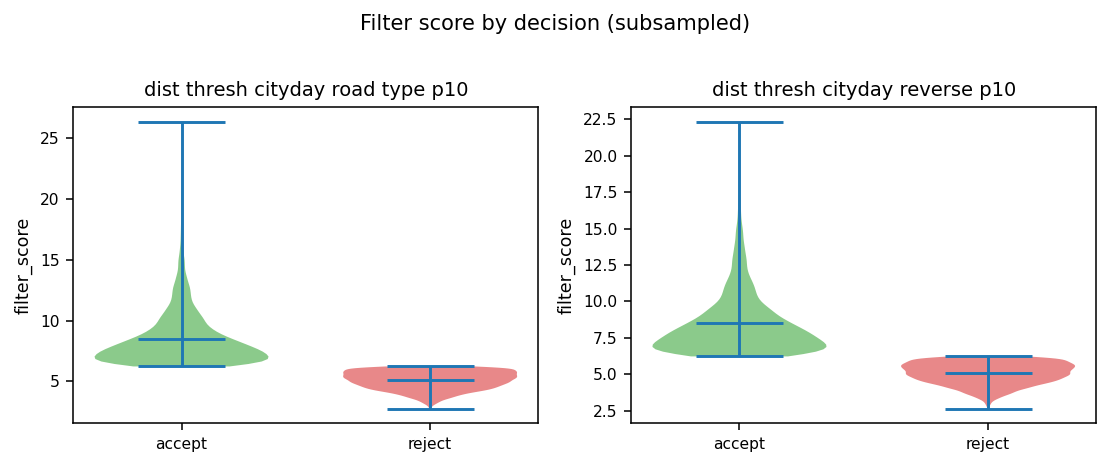

In [7]:
def plot_score_violins(label: str, df: pd.DataFrame, ax: Axes) -> None:
    if "filter_score" not in df.columns or "action" not in df.columns:
        ax.set_title(f"{label}: missing columns")
        return
    sub = ah.subsample_decisions(df, min(SUBSAMPLE_N, len(df)), RNG)
    parts = []
    for act, color in [("accept", "#2ca02c"), ("reject", "#d62728")]:
        s = sub.loc[sub["action"] == act, "filter_score"].astype(float)
        if len(s) > 0:
            parts.append((act, s.to_numpy(dtype=float, copy=False), color))
    if not parts:
        return
    positions = list(range(1, len(parts) + 1))
    vp = ax.violinplot([p[1] for p in parts], positions=positions,
                       widths=0.7, showmeans=True, showextrema=True)
    for i, body in enumerate(vp["bodies"]):  # type: ignore[arg-type]
        body.set_facecolor(parts[i][2])
        body.set_alpha(0.55)
    ax.set_xticks(positions)
    ax.set_xticklabels([p[0] for p in parts])
    ax.set_ylabel("filter_score")
    ax.set_title(label.replace("_", " "))


score_keys = [k for k in ENRICHED
              if ("distribution" in k or "dist_thresh" in k)
              and "filter_score" in ENRICHED[k].columns]
if not score_keys:
    print("No score-based runs loaded.")
else:
    n_sk = len(score_keys)
    fig, axes = plt.subplots(1, min(n_sk, 4), figsize=(4 * min(n_sk, 4), 3.2), squeeze=False)
    for a, key in zip(axes[0], score_keys[:4]):
        plot_score_violins(key, ENRICHED[key], a)
    fig.suptitle("Filter score by decision (subsampled)", y=1.02)
    plt.tight_layout()
    plt.show()

## 5 Acceptance-rate breakdown

Within a single domain block (e.g. city), acceptance rate can spike because the
stream contains intra-domain distribution shifts (night frames, rain, snow, fog,
seasonal changes).  The plots below overlay metadata composition on the
acceptance rate so we can attribute spikes to specific conditions.

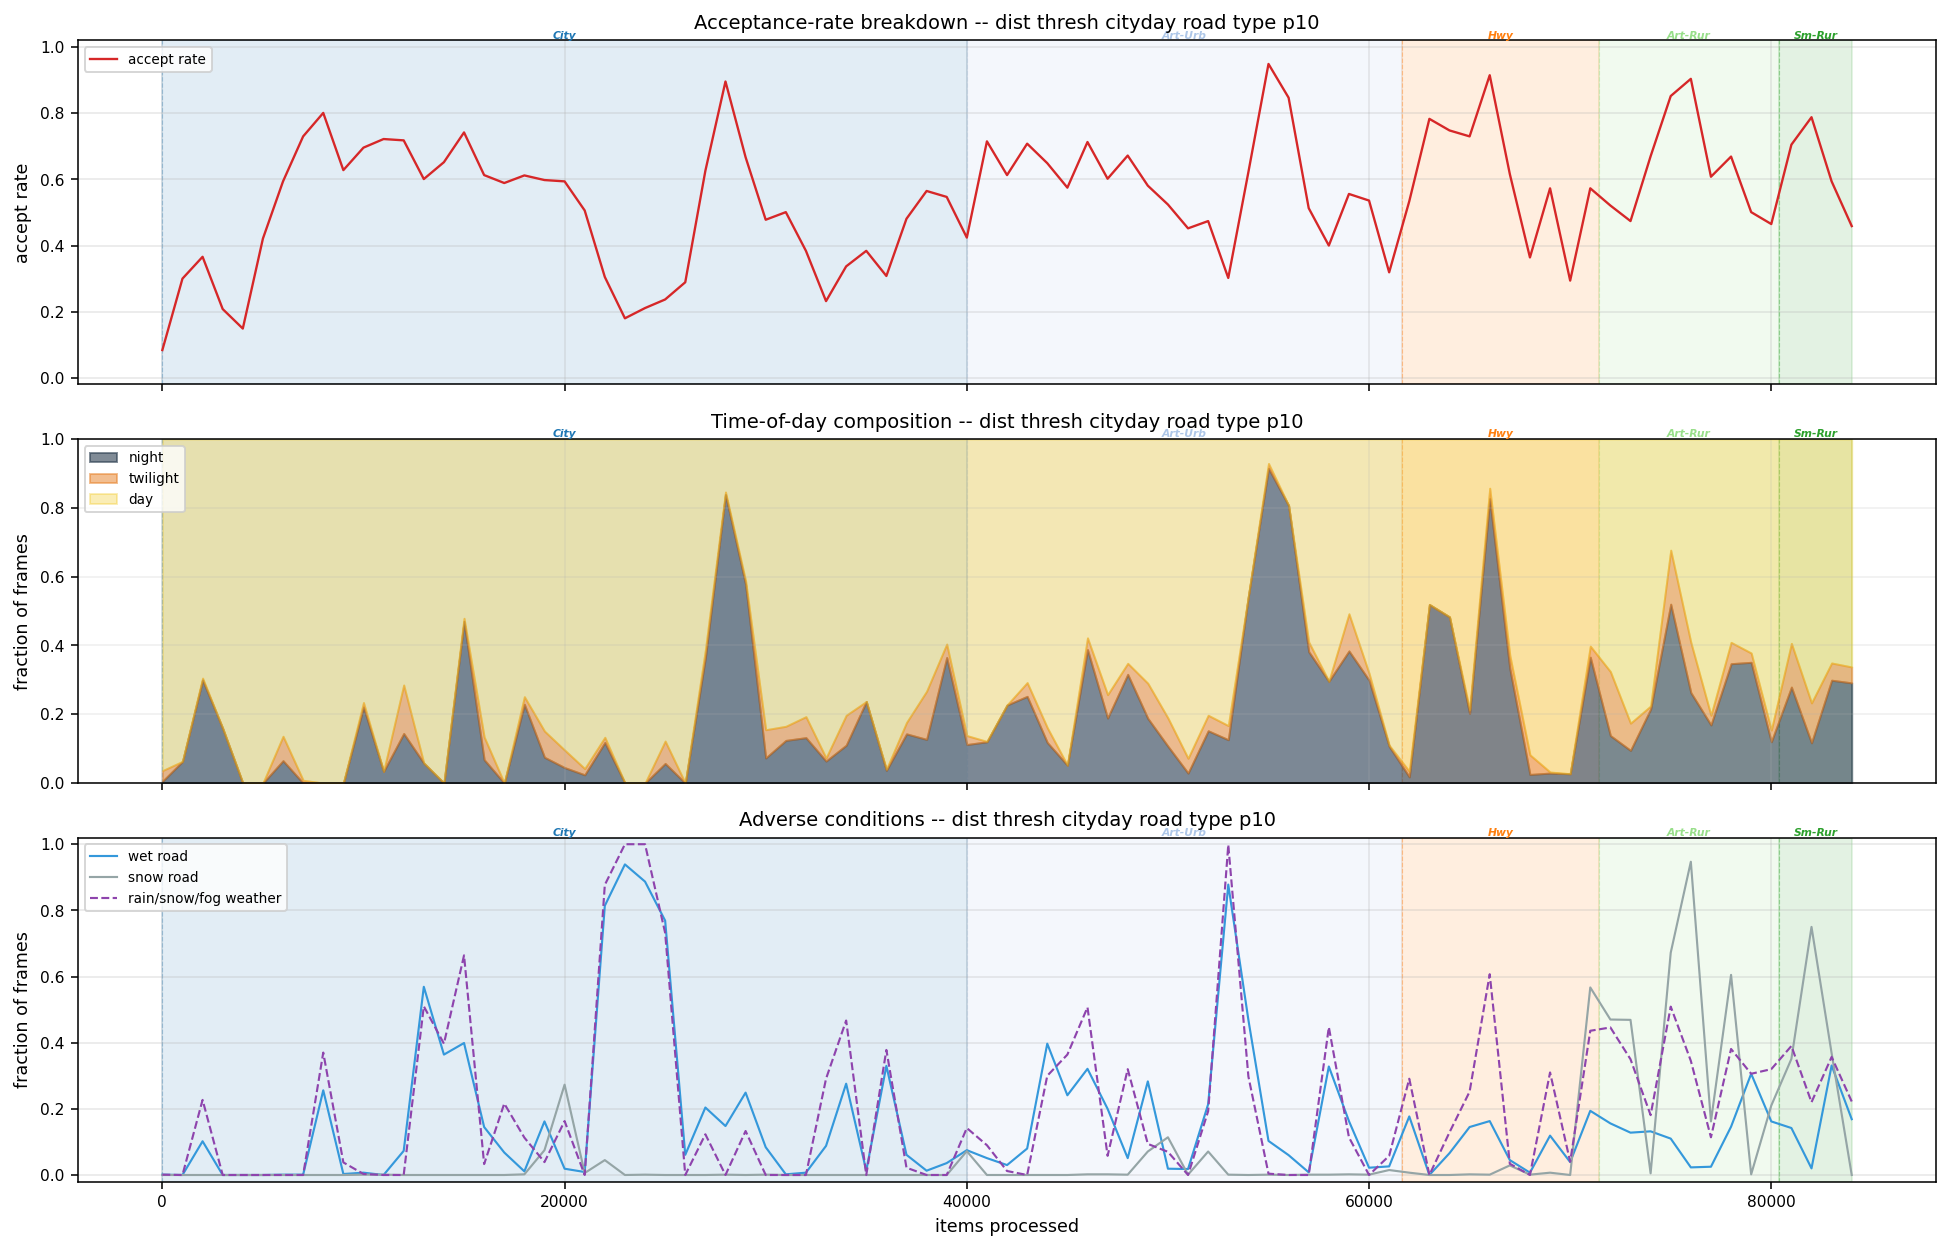

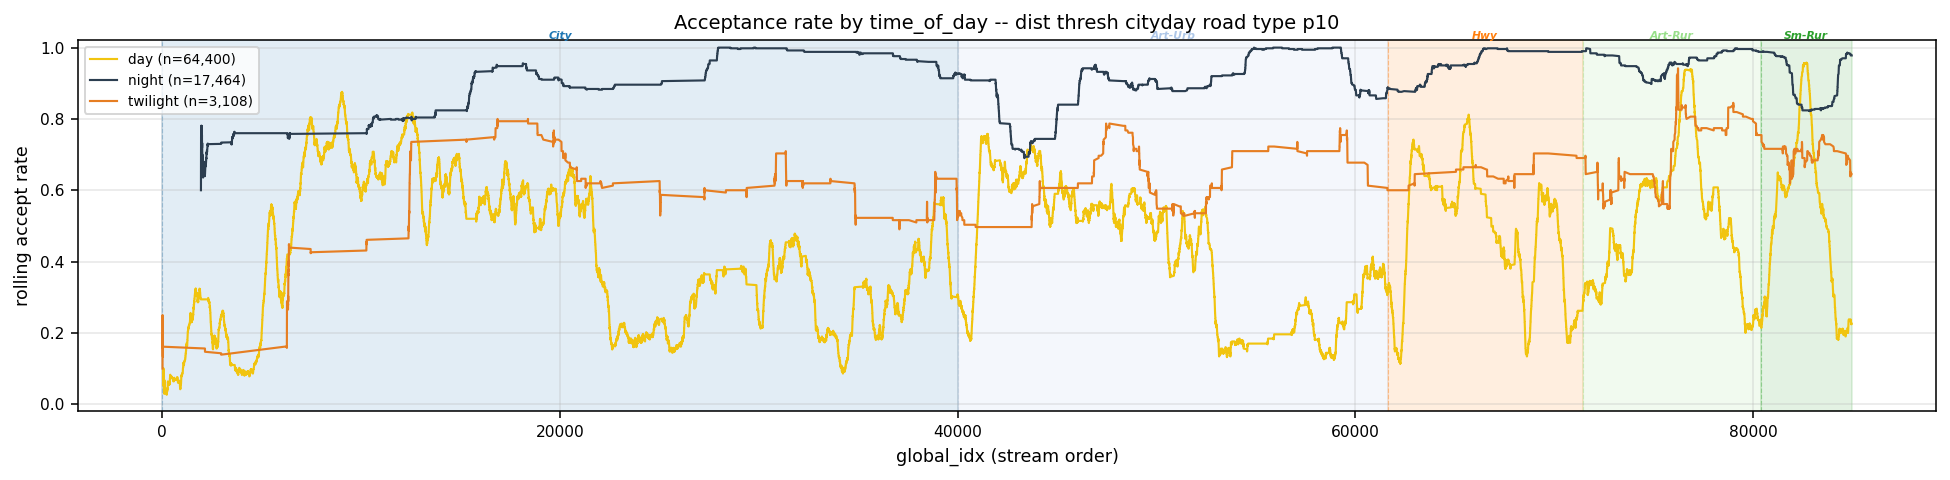

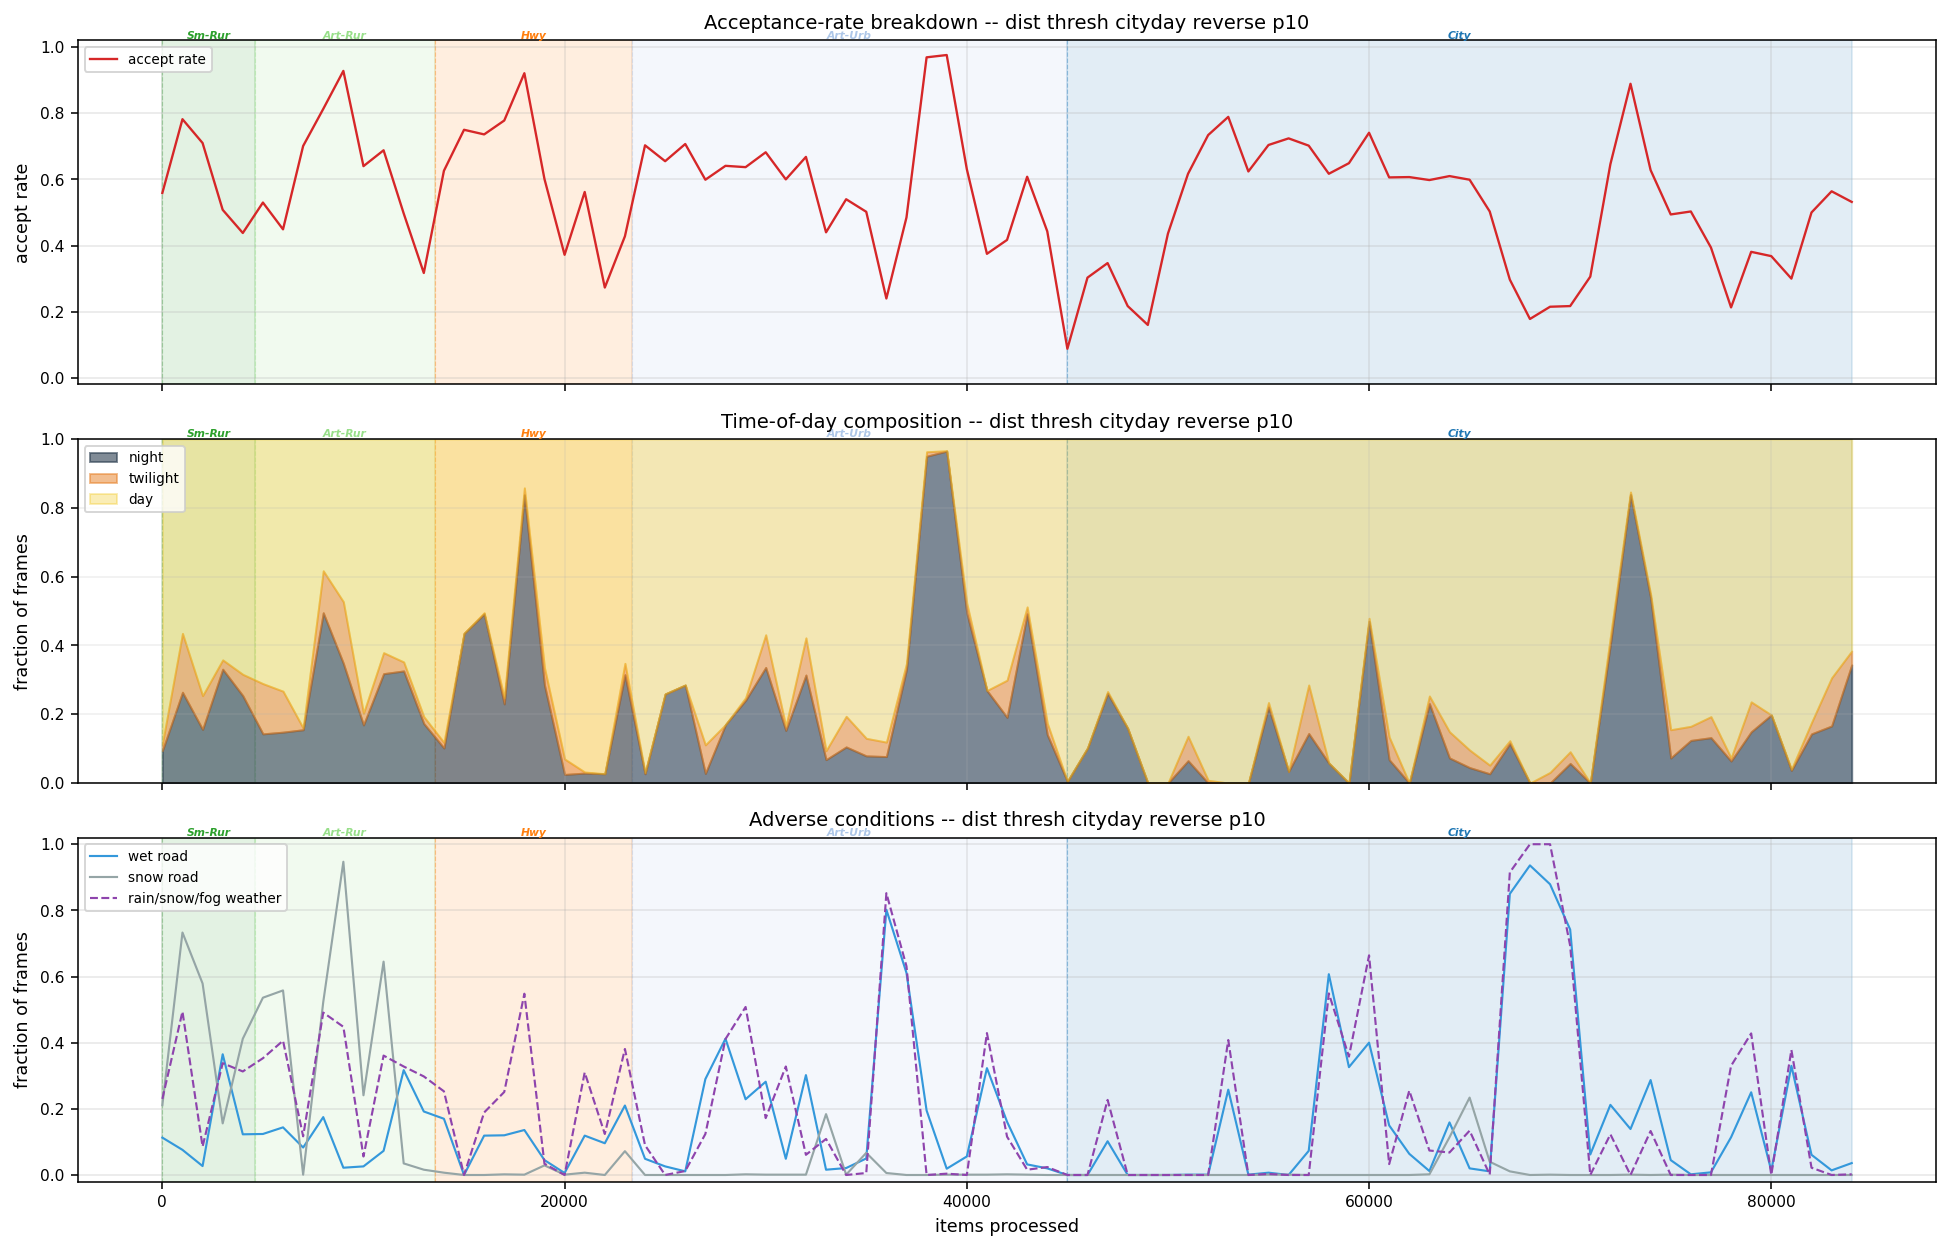

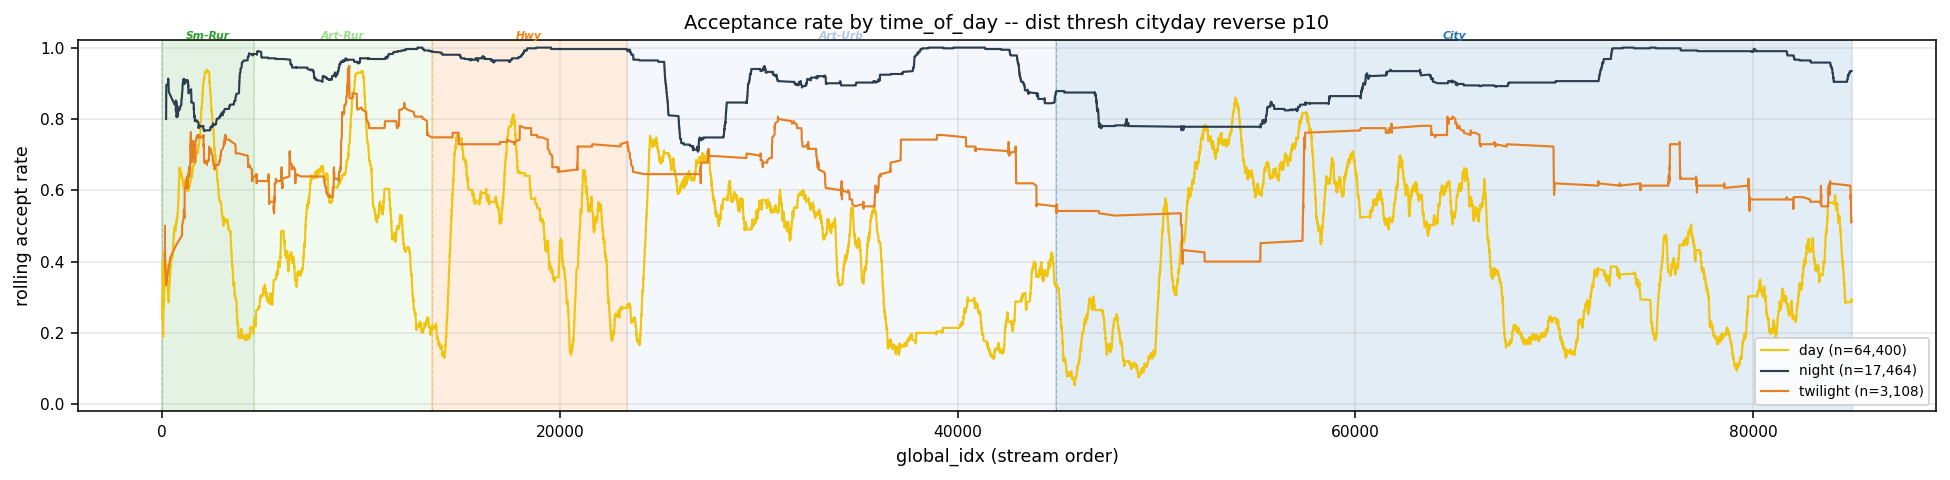

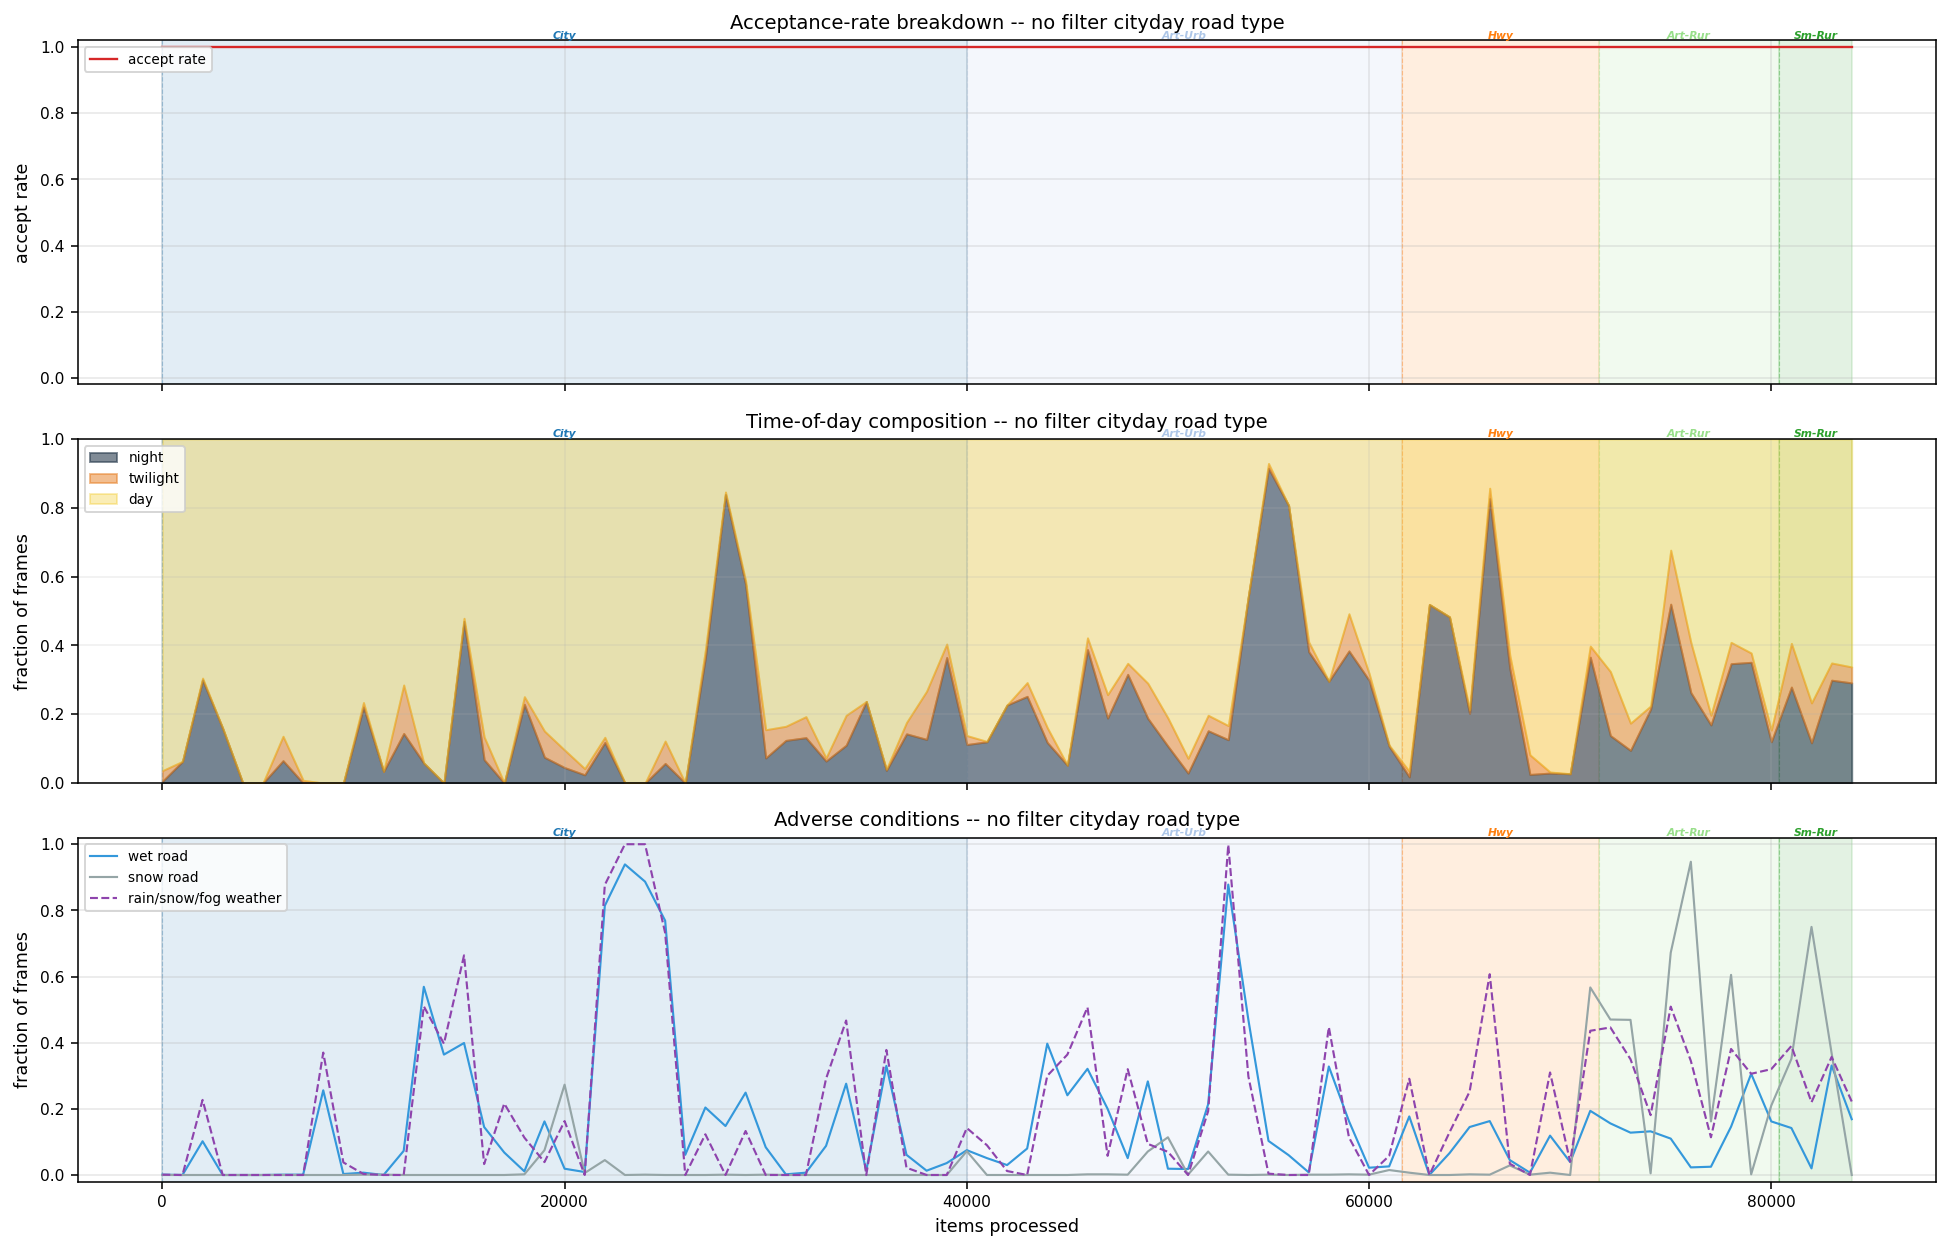

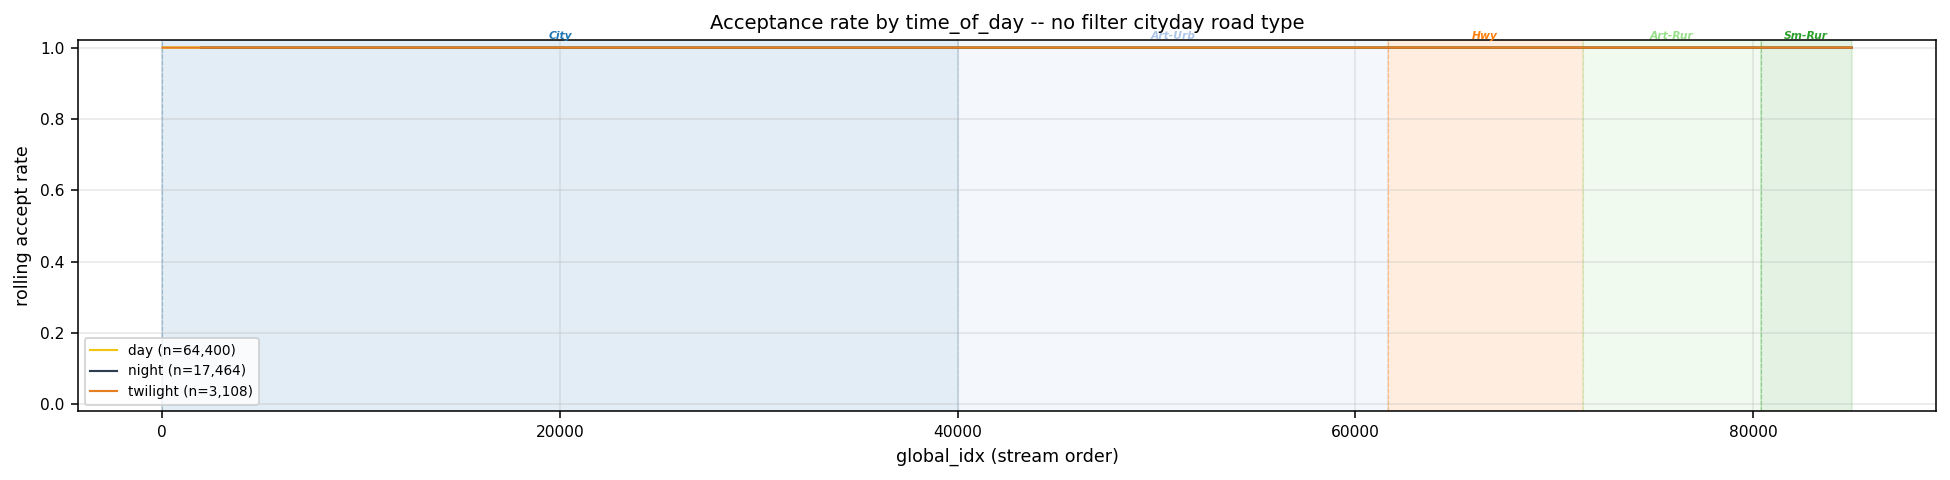

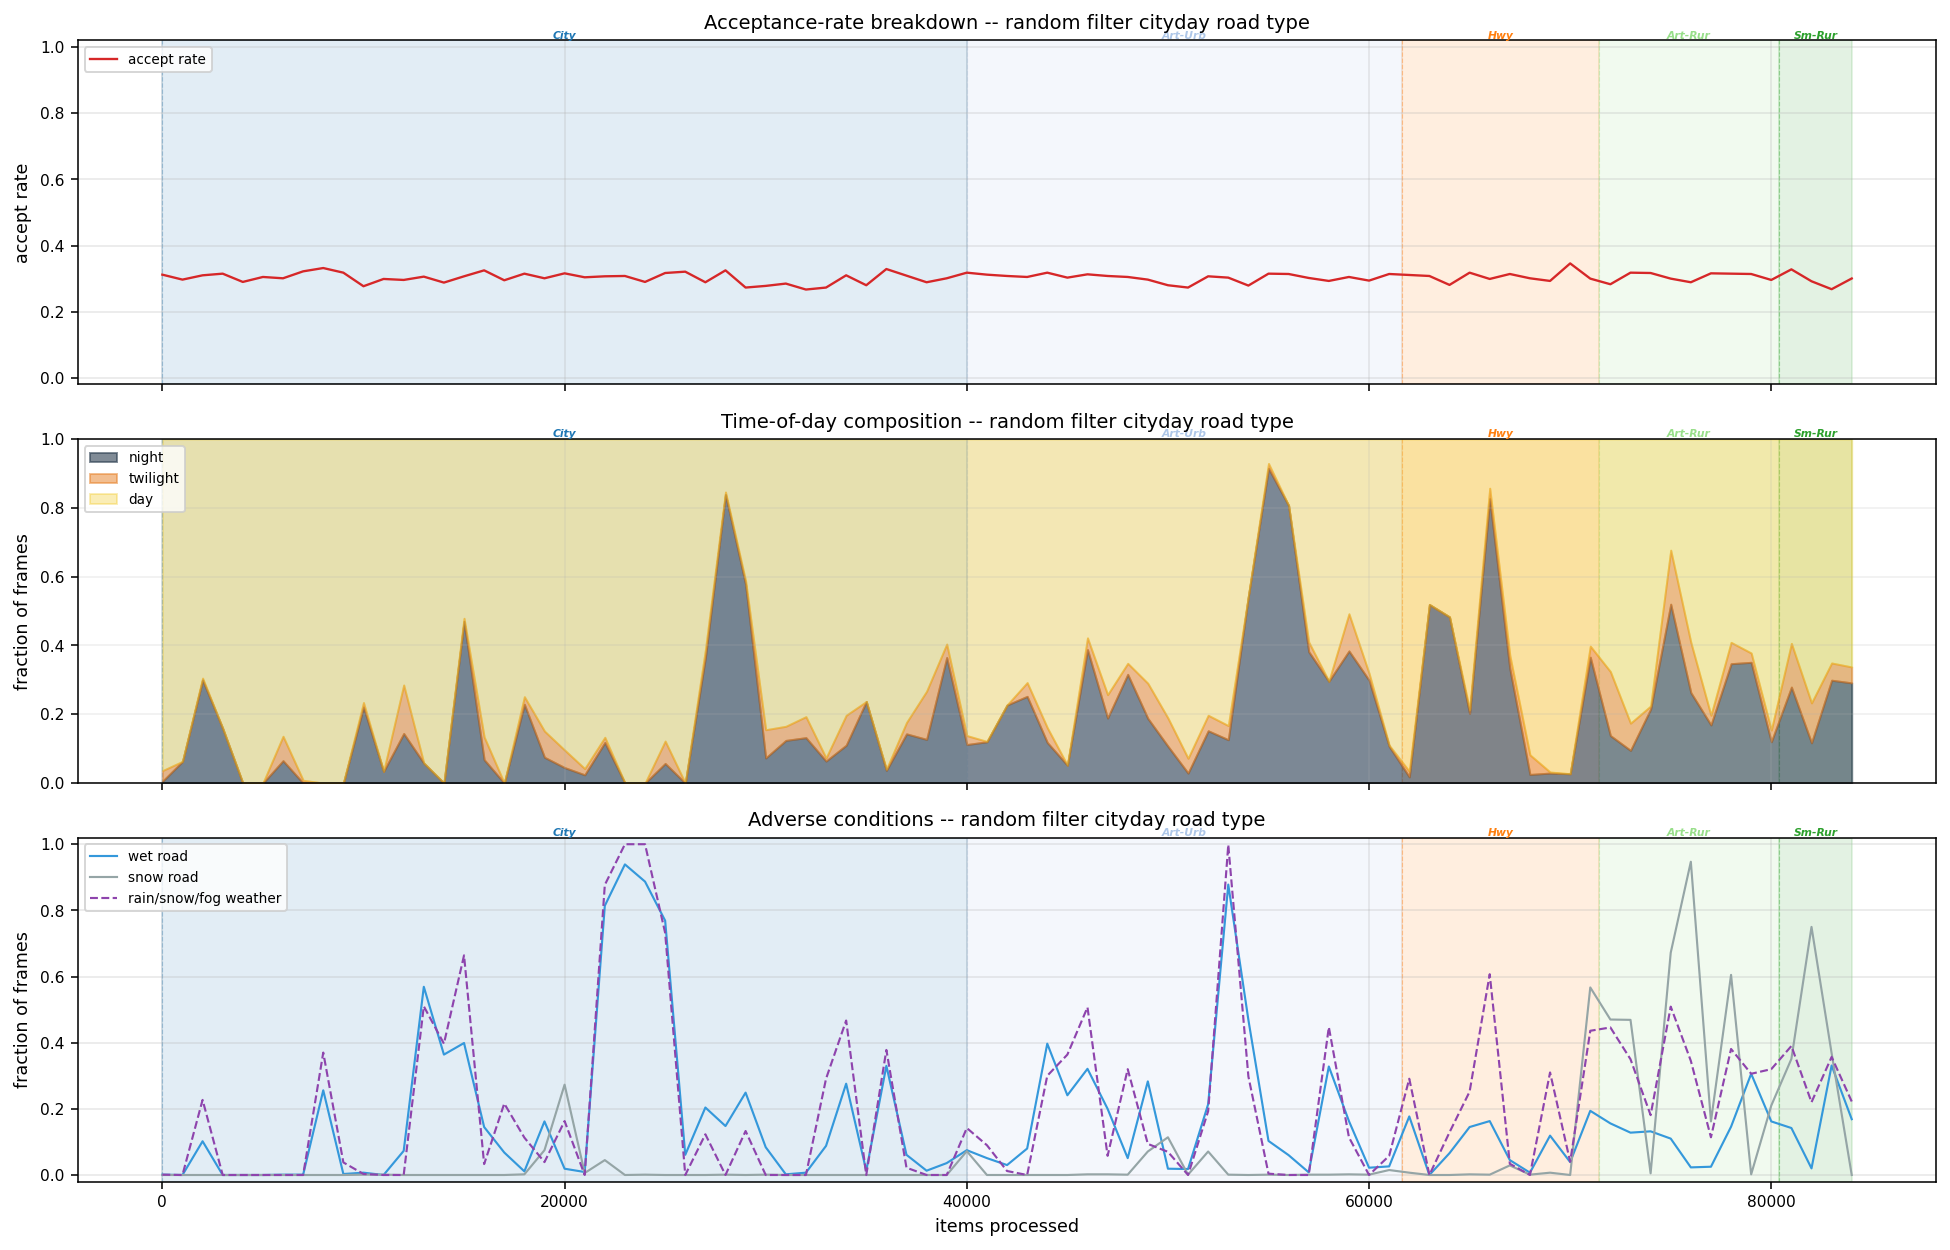

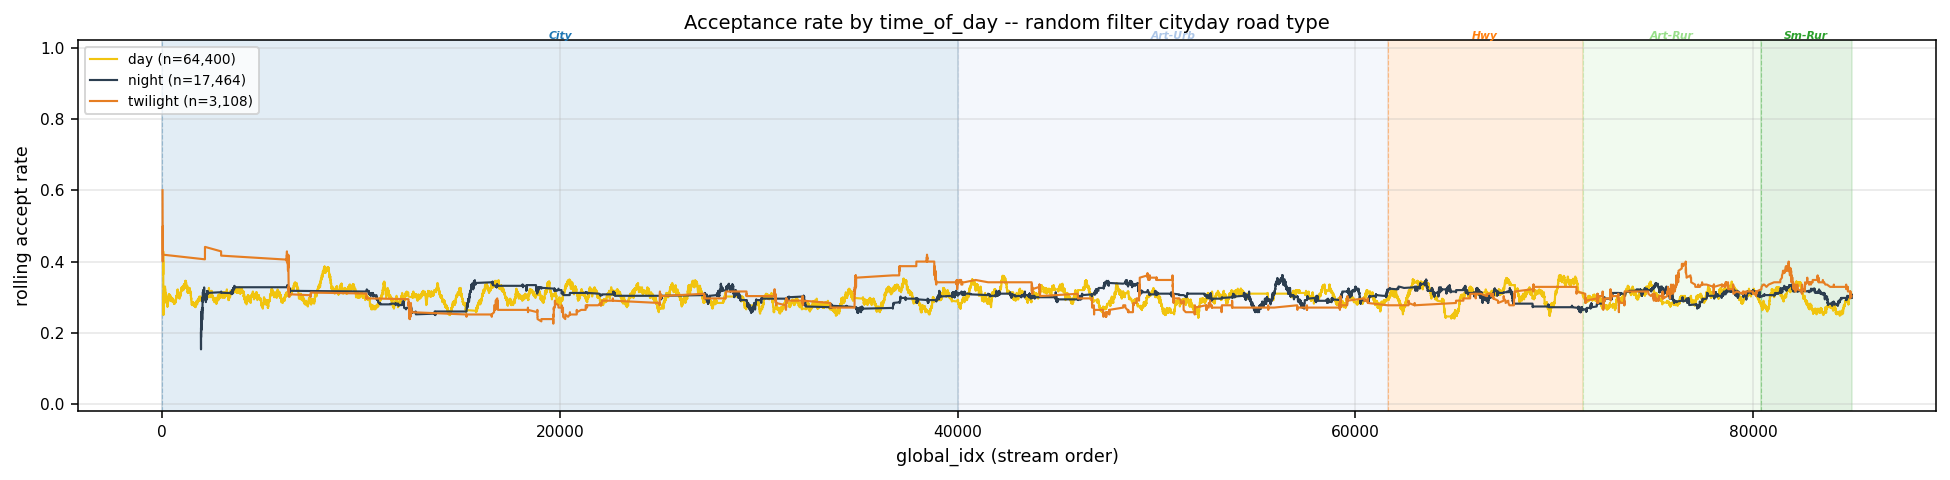

In [8]:
# Produce one set of plots per variant so each gets its own domain bands.
_dist_keys = [k for k in variants_main if k in ENRICHED]
_cp_interval = 1000

if not _dist_keys:
    print("No enriched decisions available yet.")

for _ekey in _dist_keys:
    _edf = ENRICHED[_ekey].sort_values("global_idx").copy()
    _edf["is_accept"] = (_edf["action"] == "accept").astype(int)
    _edf["window"] = _edf["global_idx"] // _cp_interval

    _window_stats: list[dict] = []
    for win_id, grp in _edf.groupby("window"):
        n = len(grp)
        accepts = grp["is_accept"].sum()
        _wid = int(win_id)  # type: ignore[arg-type]
        row: dict = {"window": _wid, "items_start": _wid * _cp_interval,
               "n": n, "accepts": accepts, "accept_rate": accepts / max(n, 1)}
        if "time_of_day" in grp.columns:
            for tod in ["day", "night", "twilight"]:
                row[f"frac_{tod}"] = (grp["time_of_day"] == tod).sum() / max(n, 1)
        if "road_condition" in grp.columns:
            for rc in ["wet", "snow"]:
                row[f"frac_{rc}"] = (grp["road_condition"] == rc).sum() / max(n, 1)
        if "scraped_weather" in grp.columns:
            row["frac_rain_snow"] = grp["scraped_weather"].isin(
                ["rain", "snow", "fog"]).sum() / max(n, 1)
        _window_stats.append(row)

    _ws = pd.DataFrame(_window_stats)
    _nice = _ekey.replace("_", " ")

    # --- 3-panel figure: accept rate + time-of-day + adverse conditions ---
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    ax0 = axes[0]
    ax0.plot(_ws["items_start"], _ws["accept_rate"], color="#d62728", lw=1.2, label="accept rate")
    ax0.set_ylabel("accept rate")
    ax0.set_title(f"Acceptance-rate breakdown -- {_nice}")
    ax0.set_ylim(-0.02, 1.02)
    ax0.legend(fontsize=7, loc="upper left")
    ax0.grid(True, alpha=0.3)
    add_block_bands(ax0, variant=_ekey)

    ax1 = axes[1]
    if "frac_night" in _ws.columns:
        ax1.fill_between(_ws["items_start"], 0, _ws["frac_night"],
                         alpha=0.6, color="#2c3e50", label="night")
        ax1.fill_between(_ws["items_start"], _ws["frac_night"],
                         _ws["frac_night"] + _ws.get("frac_twilight", 0),
                         alpha=0.5, color="#e67e22", label="twilight")
        ax1.fill_between(_ws["items_start"],
                         _ws["frac_night"] + _ws.get("frac_twilight", 0), 1.0,
                         alpha=0.3, color="#f1c40f", label="day")
    ax1.set_ylabel("fraction of frames")
    ax1.set_title(f"Time-of-day composition -- {_nice}")
    ax1.legend(fontsize=7, loc="upper left")
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.2)
    add_block_bands(ax1, variant=_ekey)

    ax2 = axes[2]
    if "frac_wet" in _ws.columns:
        ax2.plot(_ws["items_start"], _ws["frac_wet"], label="wet road", lw=1.1, color="#3498db")
    if "frac_snow" in _ws.columns:
        ax2.plot(_ws["items_start"], _ws["frac_snow"], label="snow road", lw=1.1, color="#95a5a6")
    if "frac_rain_snow" in _ws.columns:
        ax2.plot(_ws["items_start"], _ws["frac_rain_snow"],
                 label="rain/snow/fog weather", lw=1.1, color="#8e44ad", ls="--")
    ax2.set_ylabel("fraction of frames")
    ax2.set_xlabel("items processed")
    ax2.set_title(f"Adverse conditions -- {_nice}")
    ax2.legend(fontsize=7, loc="upper left")
    ax2.set_ylim(-0.02, 1.02)
    ax2.grid(True, alpha=0.3)
    add_block_bands(ax2, variant=_ekey)

    plt.tight_layout()
    plt.show()

    # --- Conditional acceptance rate by time_of_day ---
    if "time_of_day" in _edf.columns:
        fig2, ax_cond = plt.subplots(figsize=(14, 3.5))
        for tod, color in [("day", "#f1c40f"), ("night", "#2c3e50"), ("twilight", "#e67e22")]:
            sub = _edf[_edf["time_of_day"] == tod].copy()
            if len(sub) < 50:
                continue
            win = min(500, max(20, len(sub) // 20))
            accept_s = pd.Series(sub["is_accept"])
            roll = accept_s.rolling(win, min_periods=10).mean()
            ax_cond.plot(np.asarray(sub["global_idx"]), np.asarray(roll),
                         label=f"{tod} (n={len(sub):,})", color=color, lw=1.1)
        ax_cond.set_xlabel("global_idx (stream order)")
        ax_cond.set_ylabel("rolling accept rate")
        ax_cond.set_title(f"Acceptance rate by time_of_day -- {_nice}")
        ax_cond.set_ylim(-0.02, 1.02)
        ax_cond.legend(fontsize=7)
        ax_cond.grid(True, alpha=0.3)
        add_block_bands(ax_cond, variant=_ekey)
        plt.tight_layout()
        plt.show()

## 6 Category-level acceptance

Does the distribution filter over-accept rare classes (Pedestrian, VulnerableVehicle) relative to their stream frequency?  Compare against random filter where all classes should be accepted at uniform rate.

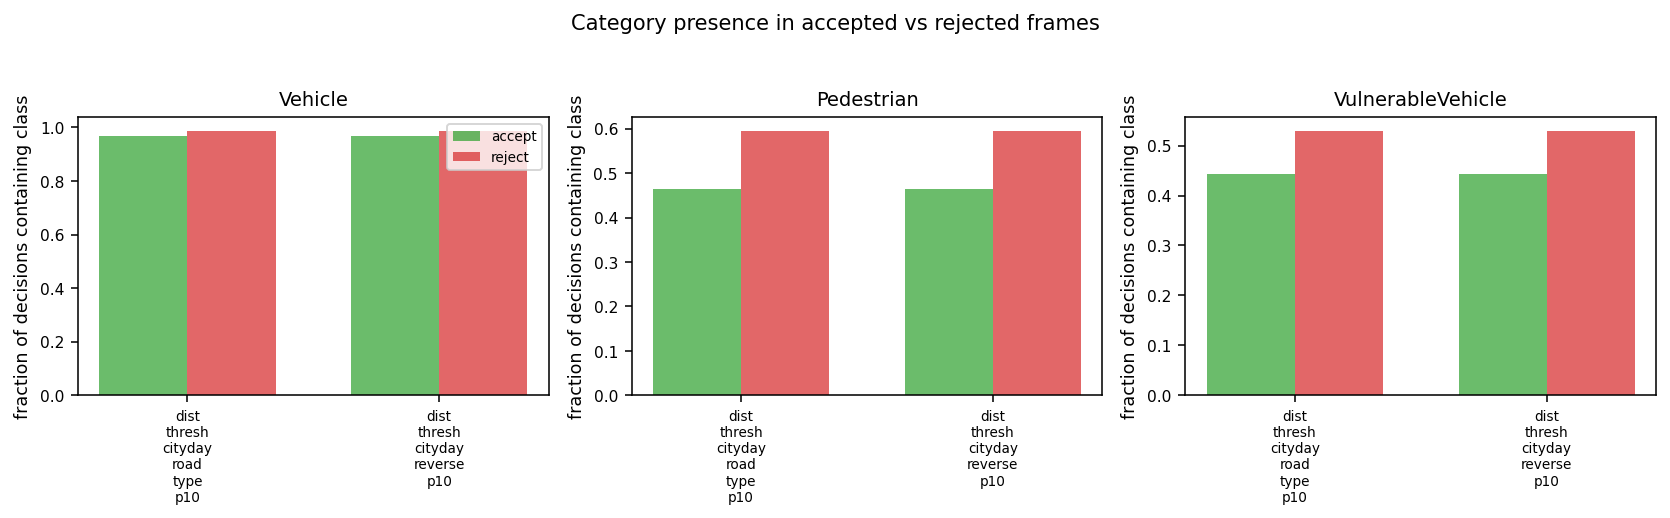

In [9]:
TARGET_CLASSES = ["Vehicle", "Pedestrian", "VulnerableVehicle"]
cat_keys = [k for k in ENRICHED if "distribution" in k or "dist_thresh" in k]

if not cat_keys:
    print("No filter runs with decisions loaded.")
else:
    rows = []
    for key in cat_keys:
        df = ENRICHED[key]
        if "categories" not in df.columns:
            continue
        for cls in TARGET_CLASSES:
            has_cls = df["categories"].fillna("").str.contains(cls)
            for action in ("accept", "reject"):
                mask = df["action"] == action
                n_with = int((mask & has_cls).sum())
                n_total = int(mask.sum())
                rows.append({"variant": key, "class": cls, "action": action,
                             "count": n_with, "fraction": n_with / max(n_total, 1)})
    cat_df = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, len(TARGET_CLASSES), figsize=(4 * len(TARGET_CLASSES), 3.5), squeeze=False)
    for i, cls in enumerate(TARGET_CLASSES):
        ax = axes[0][i]
        sub = cat_df[cat_df["class"] == cls]
        x = np.arange(len(cat_keys))
        w = 0.35
        for j, action in enumerate(("accept", "reject")):
            vals = []
            for k in cat_keys:
                sel = sub.loc[(sub["variant"] == k) & (sub["action"] == action), "fraction"]
                vals.append(float(sel.iloc[0]) if len(sel) > 0 else 0.0)
            color = "#2ca02c" if action == "accept" else "#d62728"
            ax.bar(x + j * w, vals, w, label=action, color=color, alpha=0.7)
        ax.set_xticks(x + w / 2)
        ax.set_xticklabels([k.replace("_", "\n") for k in cat_keys], fontsize=7)
        ax.set_ylabel("fraction of decisions containing class")
        ax.set_title(cls)
        if i == 0:
            ax.legend(fontsize=7)
    fig.suptitle("Category presence in accepted vs rejected frames", y=1.04)
    plt.tight_layout()
    plt.show()

## 7 Inter-accept gaps (temporal thinning)

Distribution filter may cluster accepts at domain boundaries and thin in stable regions; random sampling produces memoryless geometric gaps.

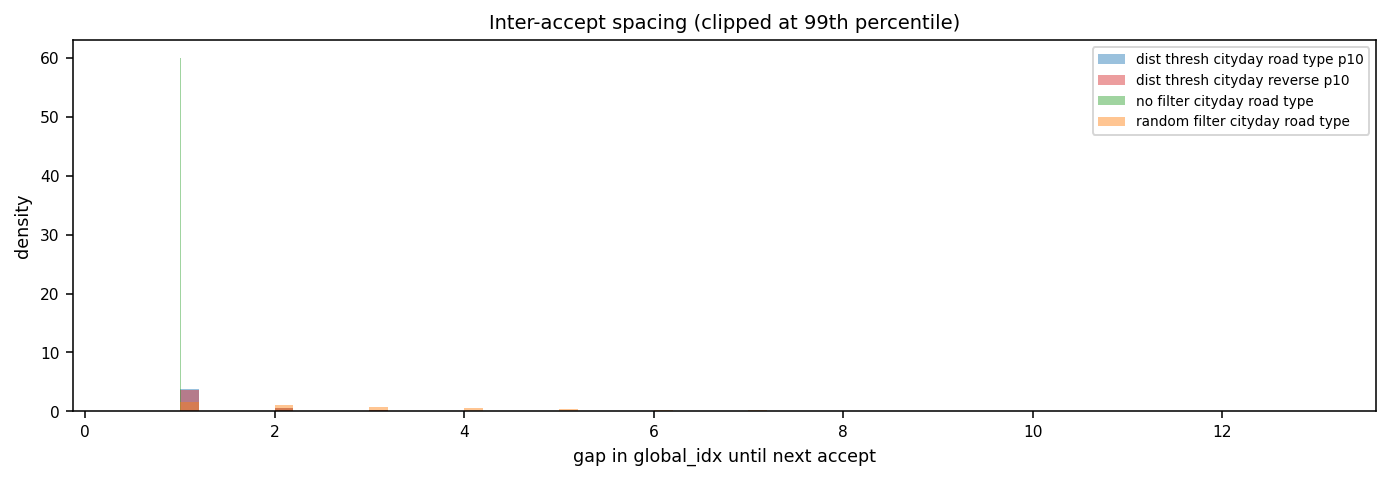

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.5))

for key in variants_main:
    if key not in ENRICHED:
        continue
    gaps = ah.inter_accept_gaps(ENRICHED[key])
    if gaps.empty:
        continue
    arr = gaps.to_numpy(dtype=float)
    cap = float(np.nanpercentile(arr, 99))
    g = np.minimum(arr, cap)
    ax.hist(g, bins=60, density=True, alpha=0.45,
            label=key.replace("_", " "), color=PALETTE.get(key))

ax.set_xlabel("gap in global_idx until next accept")
ax.set_ylabel("density")
ax.legend(fontsize=7)
ax.set_title("Inter-accept spacing (clipped at 99th percentile)")
plt.tight_layout()
plt.show()

## 8 Object-count scatter (accepted frames)

Accepted frames from distribution filter vs random -- does distribution preferentially select denser scenes (more objects)?

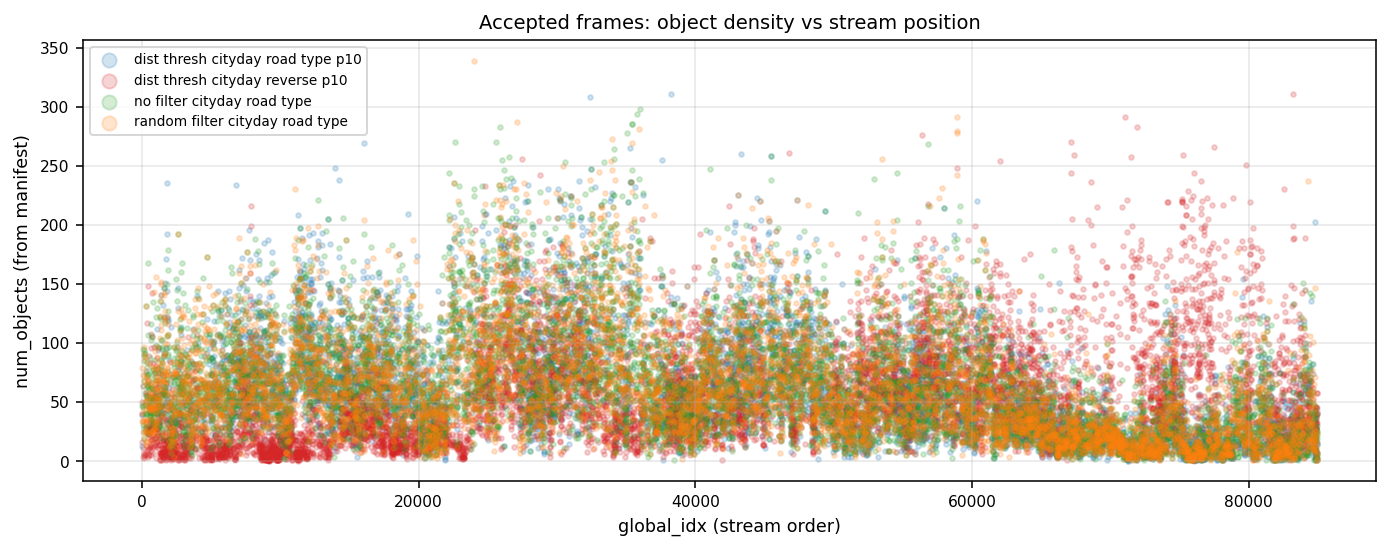

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

for key in variants_main:
    if key not in ENRICHED:
        continue
    sub = ENRICHED[key].loc[ENRICHED[key]["action"] == "accept"]
    sub = ah.subsample_decisions(sub, min(8000, len(sub)), RNG)
    if "global_idx" not in sub.columns or "num_objects" not in sub.columns:
        continue
    ax.scatter(sub["global_idx"], sub["num_objects"], s=6, alpha=0.2, rasterized=True,
               c=PALETTE.get(key), label=key.replace("_", " "))

ax.set_xlabel("global_idx (stream order)")
ax.set_ylabel("num_objects (from manifest)")
ax.legend(markerscale=3, fontsize=7)
ax.set_title("Accepted frames: object density vs stream position")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9 Forgetting analysis

Compare mean per-class AP in the first vs last stream quartile.  A negative delta signals the model degraded on that class over the stream -- proxy for catastrophic forgetting under domain shift.

                          variant             class  early_AP  late_AP   delta
dist_thresh_cityday_road_type_p10           Vehicle    0.3894   0.4116  0.0223
dist_thresh_cityday_road_type_p10        Pedestrian    0.1724   0.1648 -0.0076
dist_thresh_cityday_road_type_p10 VulnerableVehicle    0.1881   0.1923  0.0041
  dist_thresh_cityday_reverse_p10           Vehicle    0.3907   0.4145  0.0238
  dist_thresh_cityday_reverse_p10        Pedestrian    0.1508   0.1821  0.0312
  dist_thresh_cityday_reverse_p10 VulnerableVehicle    0.1710   0.2009  0.0299
      no_filter_cityday_road_type           Vehicle    0.3986   0.4224  0.0238
      no_filter_cityday_road_type        Pedestrian    0.1777   0.1683 -0.0094
      no_filter_cityday_road_type VulnerableVehicle    0.1864   0.1975  0.0111
  random_filter_cityday_road_type           Vehicle    0.3883   0.4072  0.0189
  random_filter_cityday_road_type        Pedestrian    0.1710   0.1635 -0.0075
  random_filter_cityday_road_type VulnerableVehicle 

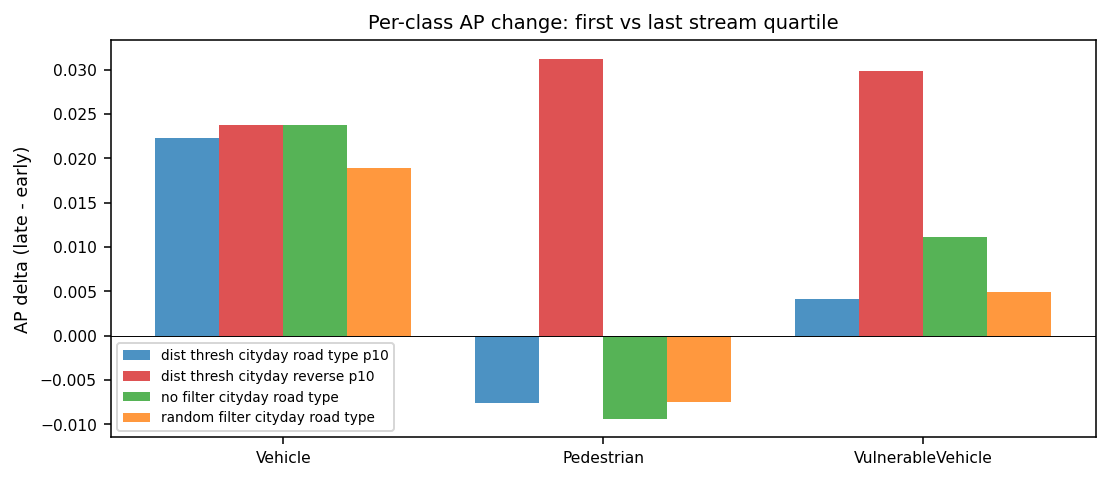

In [12]:
forget_rows = []
for v in variants_main:
    if v not in RUN:
        continue
    ck = ah.read_csv(RUN[v] / "checkpoints.csv")
    if ck is None or ck.empty:
        continue
    cols = ah.per_class_ap_columns(ck)
    if not cols:
        continue
    ft = ah.forgetting_table(ck, cols, n_bins=4)
    if ft.empty:
        continue
    for cls_col, row in ft.iterrows():
        forget_rows.append({
            "variant": v,
            "class": str(cls_col).replace("AP_", ""),
            "early_AP": row["early"],
            "late_AP": row["late"],
            "delta": row["delta"],
        })

if forget_rows:
    fdf = pd.DataFrame(forget_rows)
    print(fdf.to_string(index=False, float_format="%.4f"))

    fig, ax = plt.subplots(figsize=(8, 3.5))
    classes = fdf["class"].unique()
    variants = fdf["variant"].unique()
    x = np.arange(len(classes))
    w = 0.8 / len(variants)
    for i, v in enumerate(variants):
        sub = fdf[fdf["variant"] == v]
        deltas = []
        for c in classes:
            sel = sub.loc[sub["class"] == c, "delta"]
            deltas.append(float(sel.iloc[0]) if not sel.empty else 0.0)
        ax.bar(x + i * w, deltas, w, label=v.replace("_", " "),
               color=PALETTE.get(v, "#999"), alpha=0.8)
    ax.set_xticks(x + w * (len(variants) - 1) / 2)
    ax.set_xticklabels(classes)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("AP delta (late - early)")
    ax.set_title("Per-class AP change: first vs last stream quartile")
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("No checkpoint data with per-class AP found.")

## 10 Summary table

Best/last mAP and duration for each variant.

In [13]:
summary_rows = [ah.build_summary_row(k, v) for k, v in RUN.items()]
summary_df = pd.DataFrame(summary_rows)
cols_show = ["experiment", "seed", "filter_policy", "best_mAP", "last_mAP", "duration_h"]
cols_show = [c for c in cols_show if c in summary_df.columns]
summary_df[cols_show]

,experiment,seed,filter_policy,best_mAP,last_mAP,duration_h
0,dist_thresh_cityday_road_type_p10,42,distribution,0.2657,0.2650,7.54
1,dist_thresh_cityday_reverse_p10,42,distribution,0.2677,0.2667,7.97
2,no_filter_cityday_road_type,42,none,0.2729,0.2702,7.54
3,random_filter_cityday_road_type,42,random,0.2619,0.2597,7.02


## 11 Per-domain acceptance breakdown

Accept rate broken down by domain block (scene_bucket from manifest).
Shows where each policy spends its annotation budget.

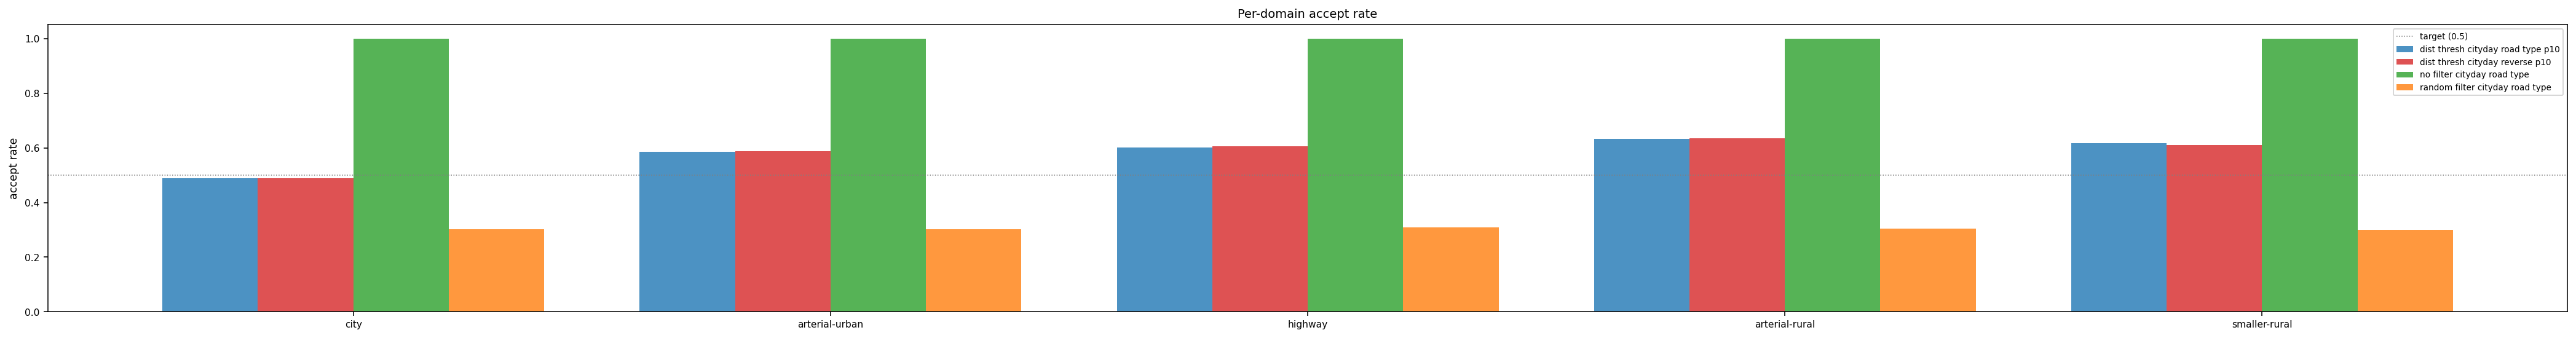

                          variant         domain  accept_rate  accepts  total
dist_thresh_cityday_road_type_p10           city     0.488866    19560  40011
dist_thresh_cityday_road_type_p10 arterial-urban     0.586121    12669  21615
dist_thresh_cityday_road_type_p10        highway     0.601693     5899   9804
dist_thresh_cityday_road_type_p10 arterial-rural     0.632314     5663   8956
dist_thresh_cityday_road_type_p10  smaller-rural     0.617968     2834   4586
  dist_thresh_cityday_reverse_p10  smaller-rural     0.609246     2794   4586
  dist_thresh_cityday_reverse_p10 arterial-rural     0.634212     5680   8956
  dist_thresh_cityday_reverse_p10        highway     0.606793     5949   9804
  dist_thresh_cityday_reverse_p10 arterial-urban     0.587185    12692  21615
  dist_thresh_cityday_reverse_p10           city     0.489740    19595  40011
      no_filter_cityday_road_type           city     1.000000    40011  40011
      no_filter_cityday_road_type arterial-urban     1.000000   

In [14]:
# Per-domain accept rate bar chart
_domain_keys = list(variants_main)

if _domain_keys and any("scene_bucket" in ENRICHED.get(k, pd.DataFrame()).columns for k in _domain_keys):
    domain_rows: list[dict] = []
    for key in _domain_keys:
        df = ENRICHED.get(key, pd.DataFrame())
        if df.empty or "scene_bucket" not in df.columns or "action" not in df.columns:
            continue
        for bucket in df["scene_bucket"].dropna().unique():
            sub = df[df["scene_bucket"] == bucket]
            n_accept = int((sub["action"] == "accept").sum())
            n_total = len(sub)
            domain_rows.append({
                "variant": key, "domain": bucket,
                "accept_rate": n_accept / max(n_total, 1),
                "accepts": n_accept, "total": n_total,
            })
    domain_df = pd.DataFrame(domain_rows)

    if not domain_df.empty:
        domains = list(domain_df["domain"].unique())
        variants = list(domain_df["variant"].unique())
        fig, ax = plt.subplots(figsize=(max(6, 1.5 * len(domains) * len(variants)), 4))
        x = np.arange(len(domains))
        w = 0.8 / max(len(variants), 1)
        for i, v in enumerate(variants):
            sub = domain_df[domain_df["variant"] == v]
            rates = []
            for d in domains:
                sel = sub.loc[sub["domain"] == d, "accept_rate"]
                rates.append(float(sel.iloc[0]) if not sel.empty else 0.0)
            ax.bar(x + i * w, rates, w, label=v.replace("_", " "),
                   color=PALETTE.get(v, f"C{i}"), alpha=0.8)
        ax.axhline(0.5, color="grey", ls=":", lw=0.8, label="target (0.5)")
        ax.set_xticks(x + w * (len(variants) - 1) / 2)
        ax.set_xticklabels(domains, fontsize=8)
        ax.set_ylabel("accept rate")
        ax.set_title("Per-domain accept rate")
        ax.legend(fontsize=7, loc="best")
        plt.tight_layout()
        plt.show()

        print(domain_df.to_string(index=False))
else:
    print("No scene_bucket data in enriched decisions.")

## 12 Cumulative accepts over time

Cumulative number of accepted frames vs stream index.
Random should be a straight line; distribution should show step-like increases at domain transitions.

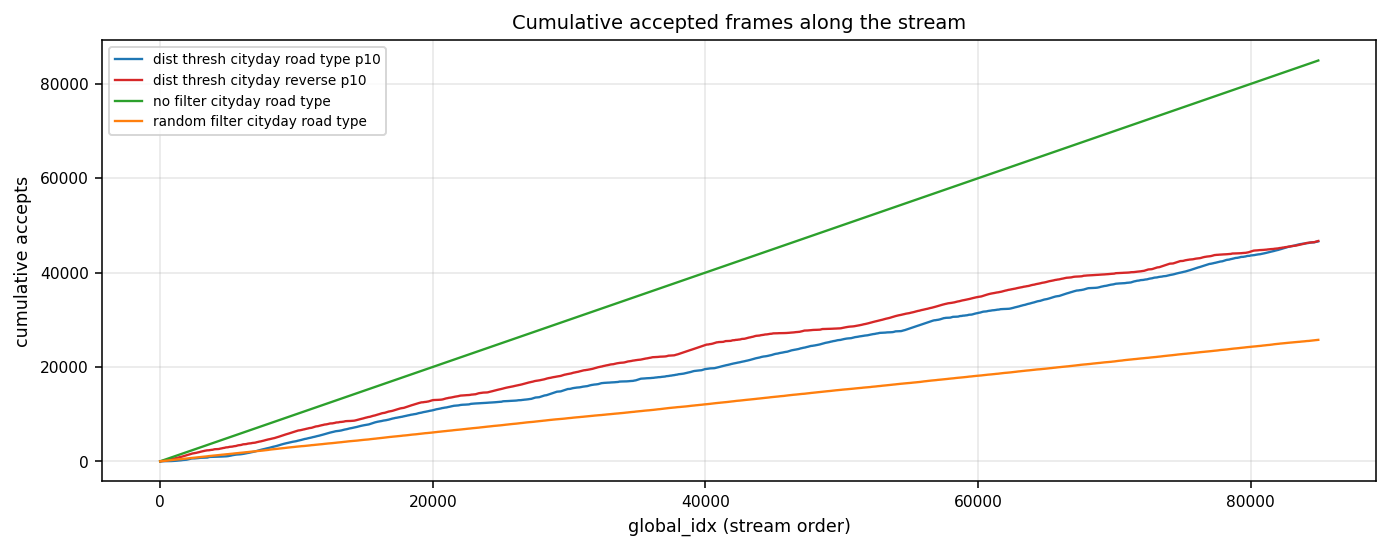

In [15]:
# Cumulative accepts over stream index
fig, ax = plt.subplots(figsize=(10, 4))
for key in variants_main:
    df = ENRICHED.get(key, pd.DataFrame())
    if df.empty or "global_idx" not in df.columns or "action" not in df.columns:
        continue
    df_sorted = df.sort_values("global_idx")
    cum_accept = (df_sorted["action"] == "accept").cumsum()
    ax.plot(df_sorted["global_idx"].to_numpy(), cum_accept.to_numpy(),
            label=key.replace("_", " "), color=PALETTE.get(key), lw=1.2)

ax.set_xlabel("global_idx (stream order)")
ax.set_ylabel("cumulative accepts")
ax.set_title("Cumulative accepted frames along the stream")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13 Pedestrian AP

Pedestrian presence varies dramatically across domains (85% city, 2% highway).
This plot tracks Pedestrian AP through the stream to highlight the domain-shift impact on a specific class.

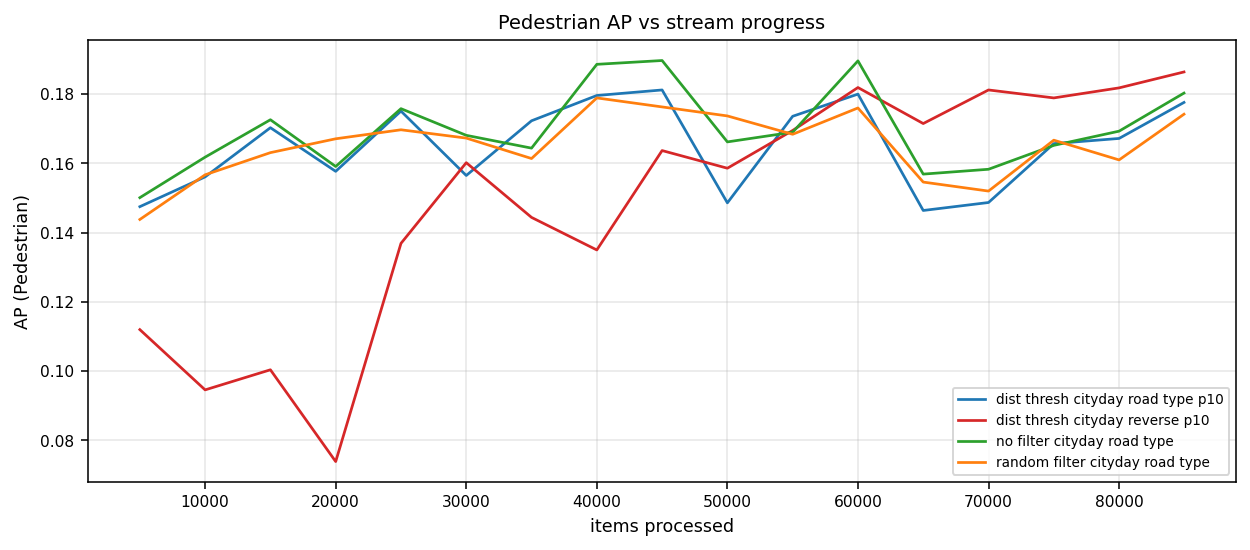

In [16]:
# Pedestrian AP vs stream progress (headline class)
_ped_col = "AP_Pedestrian"
fig, ax = plt.subplots(figsize=(9, 4))

for v in variants_main:
    if v not in RUN:
        continue
    ck = ah.read_csv(RUN[v] / "checkpoints.csv")
    if ck is None or ck.empty or _ped_col not in ck.columns:
        continue
    ax.plot(ck["items_processed"], ck[_ped_col],
            label=v.replace("_", " "), color=PALETTE.get(v), lw=1.4)

ax.set_xlabel("items processed")
ax.set_ylabel("AP (Pedestrian)")
ax.set_title("Pedestrian AP vs stream progress")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14 Per-domain mAP summary

Average mAP computed from checkpoints falling within each domain block.
Shows how well each method performs in each road-type domain.

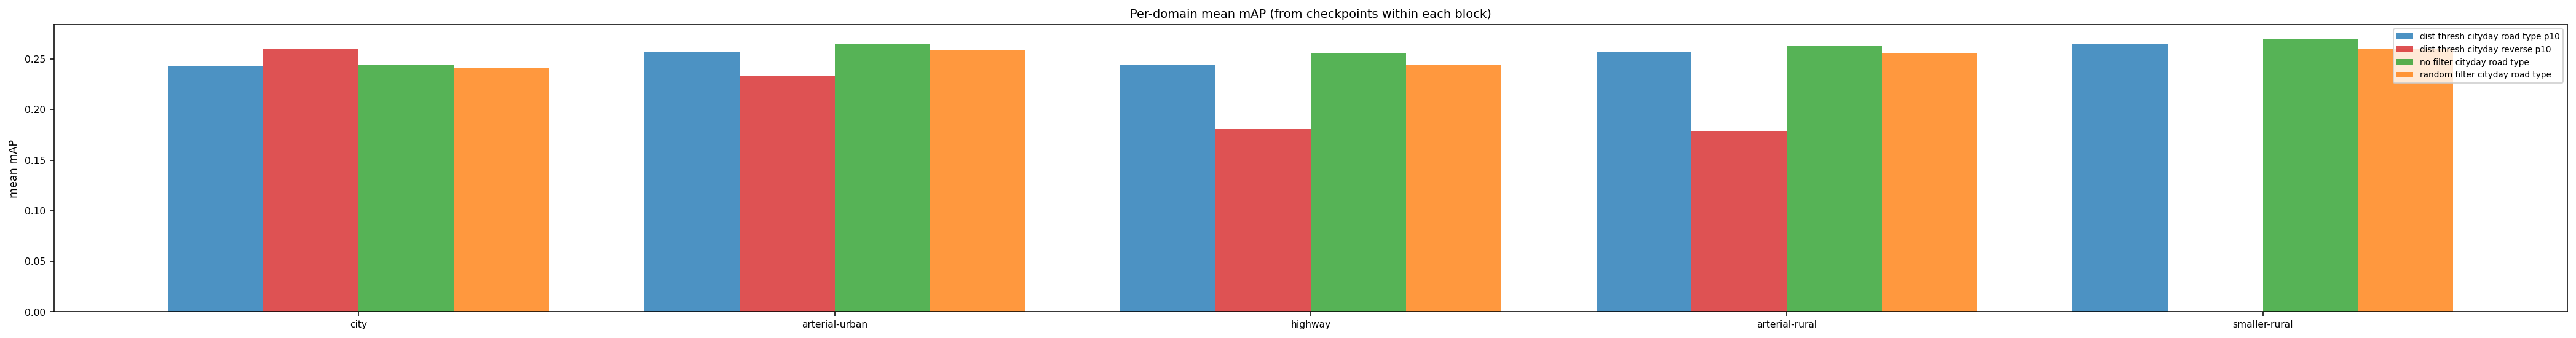


Pedestrian AP by domain:
variant         dist_thresh_cityday_reverse_p10  dist_thresh_cityday_road_type_p10  no_filter_cityday_road_type  random_filter_cityday_road_type
domain                                                                                                                                          
city                                     0.1748                             0.1644                       0.1676                           0.1635
arterial-urban                           0.1441                             0.1709                       0.1786                           0.1736
highway                                  0.0872                             0.1476                       0.1576                           0.1533
arterial-rural                           0.1033                             0.1664                       0.1673                           0.1638
smaller-rural                               NaN                             0.1776                      

In [17]:
# Per-domain mAP (using per-variant block transitions to assign checkpoints)
if BLOCK_TRANS_PER_RUN:
    domain_map_rows: list[dict] = []
    all_domains_ordered: list[str] = []
    for v in variants_main:
        if v not in RUN or v not in BLOCK_TRANS_PER_RUN:
            continue
        _bt = BLOCK_TRANS_PER_RUN[v]
        if not _bt:
            continue
        ck = ah.read_csv(RUN[v] / "checkpoints.csv")
        if ck is None or ck.empty or "mAP" not in ck.columns:
            continue
        for _, row in ck.iterrows():
            ip = int(row["items_processed"])  # type: ignore[arg-type]
            domain = _bt[0][1]
            for _j, (idx, lbl) in enumerate(_bt):
                if ip >= idx:
                    domain = lbl
            ped_val = row.get("AP_Pedestrian")
            domain_map_rows.append({
                "variant": v, "domain": domain, "mAP": float(row["mAP"]),
                "AP_Pedestrian": float(ped_val) if ped_val is not None else float("nan"),
            })
        if not all_domains_ordered:
            all_domains_ordered = [lbl for _, lbl in _bt]

    dm_df = pd.DataFrame(domain_map_rows)
    if not dm_df.empty and all_domains_ordered:
        variants_found: list[str] = dm_df["variant"].unique().tolist()
        agg = dm_df.groupby(["variant", "domain"])["mAP"].mean().reset_index()

        fig, ax = plt.subplots(figsize=(max(6, 1.5 * len(all_domains_ordered) * len(variants_found)), 4))
        x = np.arange(len(all_domains_ordered))
        w = 0.8 / max(len(variants_found), 1)
        for i, v in enumerate(variants_found):
            sub = agg[agg["variant"] == v]
            vals = []
            for d in all_domains_ordered:
                sel = sub.loc[sub["domain"] == d, "mAP"]
                vals.append(float(sel.iloc[0]) if not sel.empty else 0.0)
            ax.bar(x + i * w, vals, w, label=v.replace("_", " "),
                   color=PALETTE.get(v, f"C{i}"), alpha=0.8)
        ax.set_xticks(x + w * (len(variants_found) - 1) / 2)
        ax.set_xticklabels(all_domains_ordered, fontsize=8)
        ax.set_ylabel("mean mAP")
        ax.set_title("Per-domain mean mAP (from checkpoints within each block)")
        ax.legend(fontsize=7, loc="best")
        plt.tight_layout()
        plt.show()

        agg_ped = dm_df.groupby(["variant", "domain"])["AP_Pedestrian"].mean().reset_index()
        print("\nPedestrian AP by domain:")
        pivot_ped = agg_ped.pivot(  # type: ignore[call-overload]
            index="domain", columns="variant", values="AP_Pedestrian"
        )
        print(pivot_ped.reindex(all_domains_ordered).to_string(float_format="%.4f"))
else:
    print("No block transitions available.")